In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("All libraries imported!")

All libraries imported!


In [3]:
hotels_df = pd.read_csv('/kaggle/input/hotels.csv')
users_df = pd.read_csv('/kaggle/input/users.csv')
reviews_df = pd.read_csv('/kaggle/input/reviews.csv')

print("Data loaded successfully!")
print(f" Hotels: {len(hotels_df)} records")
print(f" Users: {len(users_df)} records") 
print(f" Reviews: {len(reviews_df)} records")
print(f" Columns in reviews_df: {reviews_df.columns.tolist()}")


Data loaded successfully!
 Hotels: 25 records
 Users: 2000 records
 Reviews: 50000 records
 Columns in reviews_df: ['review_id', 'user_id', 'hotel_id', 'review_date', 'score_overall', 'score_cleanliness', 'score_comfort', 'score_facilities', 'score_location', 'score_staff', 'score_value_for_money', 'review_text']


In [4]:

# Basic Dimensions and Columns
print("Dataset Dimensions and Features")
print("-" * 60)
rows, columns = hotels_df.shape
print(f"Total Records: {rows}")
print(f"Total Fields: {columns}")
print(f"Feature Names: {hotels_df.columns.tolist()}")

# Previewing Data
print("\n Preview of Dataset Entries")
print("-" * 60)
display(hotels_df.head())

# Structural Summary
print("\n Dataset Information")
print("-" * 60)
hotels_df.info()

# Country-wise Distribution
print("\n Distribution by Country")
print("-" * 60)
country_counts = hotels_df['country'].value_counts()
print(country_counts)

# Descriptive Statistics for Rating Metrics
print("\n Summary of Initial Ratings")
print("-" * 60)
initial_rating_fields = [
    'cleanliness_base',
    'comfort_base',
    'facilities_base',
    'location_base',
    'staff_base',
    'value_for_money_base'
]
rating_summary = hotels_df[initial_rating_fields].describe()
print(rating_summary)


Dataset Dimensions and Features
------------------------------------------------------------
Total Records: 25
Total Fields: 13
Feature Names: ['hotel_id', 'hotel_name', 'city', 'country', 'star_rating', 'lat', 'lon', 'cleanliness_base', 'comfort_base', 'facilities_base', 'location_base', 'staff_base', 'value_for_money_base']

 Preview of Dataset Entries
------------------------------------------------------------


,hotel_id,hotel_name,city,country,star_rating,lat,lon,cleanliness_base,comfort_base,facilities_base,location_base,staff_base,value_for_money_base
0,1,The Azure Tower,New York,United States,5,40.7580,-73.9855,9.1,8.8,8.9,9.5,8.6,8.0
1,2,The Royal Compass,London,United Kingdom,5,51.5072,-0.1276,9.0,9.2,8.8,9.4,9.0,7.9
2,3,L'Étoile Palace,Paris,France,5,48.8566,2.3522,8.8,9.4,8.7,9.6,9.3,8.1
3,4,Kyo-to Grand,Tokyo,Japan,5,35.6895,139.6917,9.6,9.0,9.3,8.5,9.5,8.2
4,5,The Golden Oasis,Dubai,United Arab Emirates,5,25.2769,55.2962,9.3,9.5,9.6,8.9,9.4,8.5



 Dataset Information
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   hotel_id              25 non-null     int64  
 1   hotel_name            25 non-null     object 
 2   city                  25 non-null     object 
 3   country               25 non-null     object 
 4   star_rating           25 non-null     int64  
 5   lat                   25 non-null     float64
 6   lon                   25 non-null     float64
 7   cleanliness_base      25 non-null     float64
 8   comfort_base          25 non-null     float64
 9   facilities_base       25 non-null     float64
 10  location_base         25 non-null     float64
 11  staff_base            25 non-null     float64
 12  value_for_money_base  25 non-null     float64
dtypes: float64(8), int64(2), object(3)
memory us

In [5]:
#users table


print("=" * 50)
print(f"Shape: {users_df.shape}")
print(f"Columns: {list(users_df.columns)}")
print("\nFirst 5 users:")
display(users_df.head())

print("\n📊 USERS DATASET SUMMARY")
print("=" * 50)
print(users_df.info())

print("\n👤 DEMOGRAPHIC BREAKDOWN")
print("=" * 50)
print("Gender Distribution:")
print(users_df['user_gender'].value_counts())
print(f"Percentage: {users_df['user_gender'].value_counts(normalize=True)*100}")

print("\n🎂 Age Group Distribution:")
print(users_df['age_group'].value_counts())

print("\n🧳 Traveller Type Distribution:")
print(users_df['traveller_type'].value_counts())

print("\n🌍 Top 10 Countries by Users:")
print(users_df['country'].value_counts().head(10))

# Convert join_date to datetime for analysis
users_df['join_date'] = pd.to_datetime(users_df['join_date'])
print(f"\n📅 User Registration Period: {users_df['join_date'].min().date()} to {users_df['join_date'].max().date()}")

Shape: (2000, 6)
Columns: ['user_id', 'user_gender', 'country', 'age_group', 'traveller_type', 'join_date']

First 5 users:


,user_id,user_gender,country,age_group,traveller_type,join_date
0,1,Female,United Kingdom,35-44,Solo,2024-09-29
1,2,Male,United Kingdom,25-34,Solo,2023-11-29
2,3,Female,Mexico,25-34,Family,2022-04-03
3,4,Male,India,35-44,Family,2023-12-02
4,5,Other,Japan,25-34,Solo,2021-12-18



📊 USERS DATASET SUMMARY
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   user_id         2000 non-null   int64 
 1   user_gender     2000 non-null   object
 2   country         2000 non-null   object
 3   age_group       2000 non-null   object
 4   traveller_type  2000 non-null   object
 5   join_date       2000 non-null   object
dtypes: int64(1), object(5)
memory usage: 93.9+ KB
None

👤 DEMOGRAPHIC BREAKDOWN
Gender Distribution:
user_gender
Male      942
Female    864
Other     194
Name: count, dtype: int64
Percentage: user_gender
Male      47.1
Female    43.2
Other      9.7
Name: proportion, dtype: float64

🎂 Age Group Distribution:
age_group
25-34    653
35-44    611
45-54    317
18-24    218
55+      201
Name: count, dtype: int64

🧳 Traveller Type Distribution:
traveller_type
Couple      694
Family      478
Solo        420
Business  

In [6]:

# Reviews Dataset

# Basic Structure
print("📝 Reviews Dataset Overview")
print("-" * 60)
print(f"Entries: {reviews_df.shape[0]}")
print(f"Attributes: {reviews_df.shape[1]}")
print(f"Available Columns: {reviews_df.columns.tolist()}")

# Preview Sample Records
print("\n🔍 Sample Review Entries")
print("-" * 60)
display(reviews_df.head(5))

# Dataset Summary
print("\n📋 Dataset Info")
print("-" * 60)
reviews_df.info()

# Ensure review_date is in datetime format
reviews_df['review_date'] = pd.to_datetime(reviews_df['review_date'])

# Temporal Trends
print("\n📅 Review Timeline")
print("-" * 60)
start_date = reviews_df['review_date'].min().date()
end_date = reviews_df['review_date'].max().date()
print(f"Date Range: {start_date} to {end_date}")

# Reviews by Year
reviews_df['year'] = reviews_df['review_date'].dt.year
print("\nReviews per Year:")
print(reviews_df['year'].value_counts().sort_index())

# Rating Columns Summary
print("\n⭐ Rating Breakdown")
print("-" * 60)
rating_fields = [
    'score_overall', 'score_cleanliness', 'score_comfort',
    'score_facilities', 'score_location', 'score_staff', 'score_value_for_money'
]
print("Summary Statistics for Rating Fields:")
display(reviews_df[rating_fields].describe())

# Reviews per Hotel
print("\n🏨 Distribution: Reviews per Hotel")
print("-" * 60)
hotel_review_counts = reviews_df['hotel_id'].value_counts().sort_index()
print(f"Average Reviews per Hotel: {hotel_review_counts.mean():.1f}")
print(f"Minimum Reviews: {hotel_review_counts.min()}")
print(f"Maximum Reviews: {hotel_review_counts.max()}")

# Reviews per User
print("\n👤 User Activity Overview")
print("-" * 60)
user_review_counts = reviews_df['user_id'].value_counts()
print(f"Average Reviews per User: {user_review_counts.mean():.1f}")
print(f"Users with >1 Review: {(user_review_counts > 1).sum()}")
print(f"Top Reviewer: {user_review_counts.max()} reviews")





📝 Reviews Dataset Overview
------------------------------------------------------------
Entries: 50000
Attributes: 12
Available Columns: ['review_id', 'user_id', 'hotel_id', 'review_date', 'score_overall', 'score_cleanliness', 'score_comfort', 'score_facilities', 'score_location', 'score_staff', 'score_value_for_money', 'review_text']

🔍 Sample Review Entries
------------------------------------------------------------


,review_id,user_id,hotel_id,review_date,score_overall,score_cleanliness,score_comfort,score_facilities,score_location,score_staff,score_value_for_money,review_text
0,1,1600,1,2022-10-07,8.7,8.6,8.7,8.5,9.0,8.8,8.7,Practice reduce young our because machine. Rec...
1,2,432,4,2020-03-24,9.1,10.0,9.1,9.0,8.6,9.4,8.6,Test cover traditional black. Process tell Mr ...
2,3,186,18,2023-12-18,8.8,9.7,8.8,8.3,8.7,8.1,8.6,Friend million student social study yeah. Grow...
3,4,1403,19,2022-06-22,8.9,9.0,8.8,8.5,9.6,9.1,8.3,Huge girl already remain truth behind card. Ap...
4,5,1723,17,2022-07-02,9.1,8.9,9.5,9.3,8.3,9.4,8.9,Cover feeling call community serve television ...



📋 Dataset Info
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   review_id              50000 non-null  int64  
 1   user_id                50000 non-null  int64  
 2   hotel_id               50000 non-null  int64  
 3   review_date            50000 non-null  object 
 4   score_overall          50000 non-null  float64
 5   score_cleanliness      50000 non-null  float64
 6   score_comfort          50000 non-null  float64
 7   score_facilities       50000 non-null  float64
 8   score_location         50000 non-null  float64
 9   score_staff            50000 non-null  float64
 10  score_value_for_money  50000 non-null  float64
 11  review_text            50000 non-null  object 
dtypes: float64(7), int64(3), object(2)
memory usage: 4.6+ MB

📅 Review Timeline
-----

,score_overall,score_cleanliness,score_comfort,score_facilities,score_location,score_staff,score_value_for_money
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,8.943460,9.052558,9.024404,8.743062,9.176410,8.972076,8.434540
std,0.180878,0.504296,0.423927,0.498320,0.421086,0.397775,0.529321
min,8.200000,7.700000,7.900000,7.600000,7.900000,7.900000,6.800000
25%,8.800000,8.700000,8.700000,8.400000,8.900000,8.700000,8.100000
50%,8.900000,9.100000,9.000000,8.700000,9.200000,9.000000,8.500000
75%,9.100000,9.400000,9.300000,9.100000,9.500000,9.200000,8.800000
max,9.600000,10.000000,10.000000,10.000000,10.000000,10.000000,9.700000



🏨 Distribution: Reviews per Hotel
------------------------------------------------------------
Average Reviews per Hotel: 2000.0
Minimum Reviews: 1902
Maximum Reviews: 2104

👤 User Activity Overview
------------------------------------------------------------
Average Reviews per User: 25.0
Users with >1 Review: 2000
Top Reviewer: 44 reviews


📉 Visualizing Missing Data


<Figure size 1000x500 with 0 Axes>

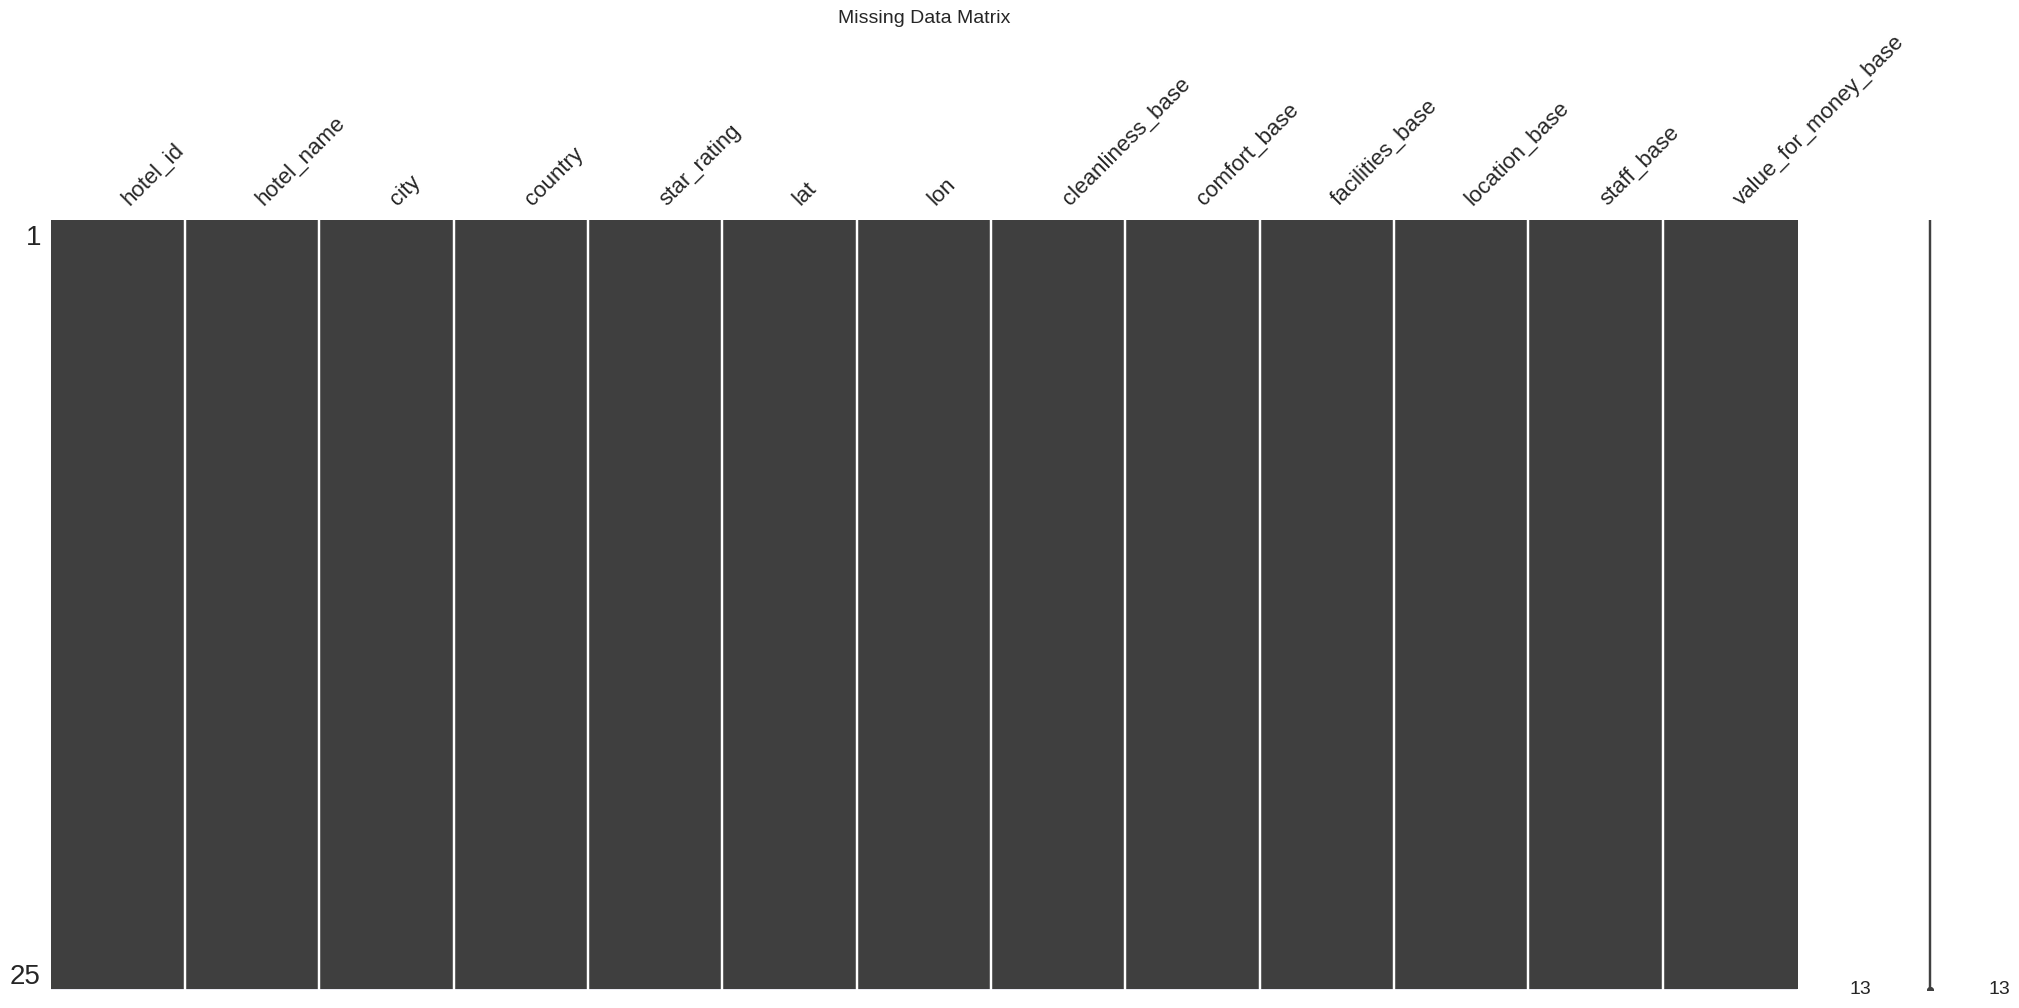


🧮 Missing Values Count
hotel_id                0
hotel_name              0
city                    0
country                 0
star_rating             0
lat                     0
lon                     0
cleanliness_base        0
comfort_base            0
facilities_base         0
location_base           0
staff_base              0
value_for_money_base    0
dtype: int64
📉 Visualizing Missing Data


<Figure size 1000x500 with 0 Axes>

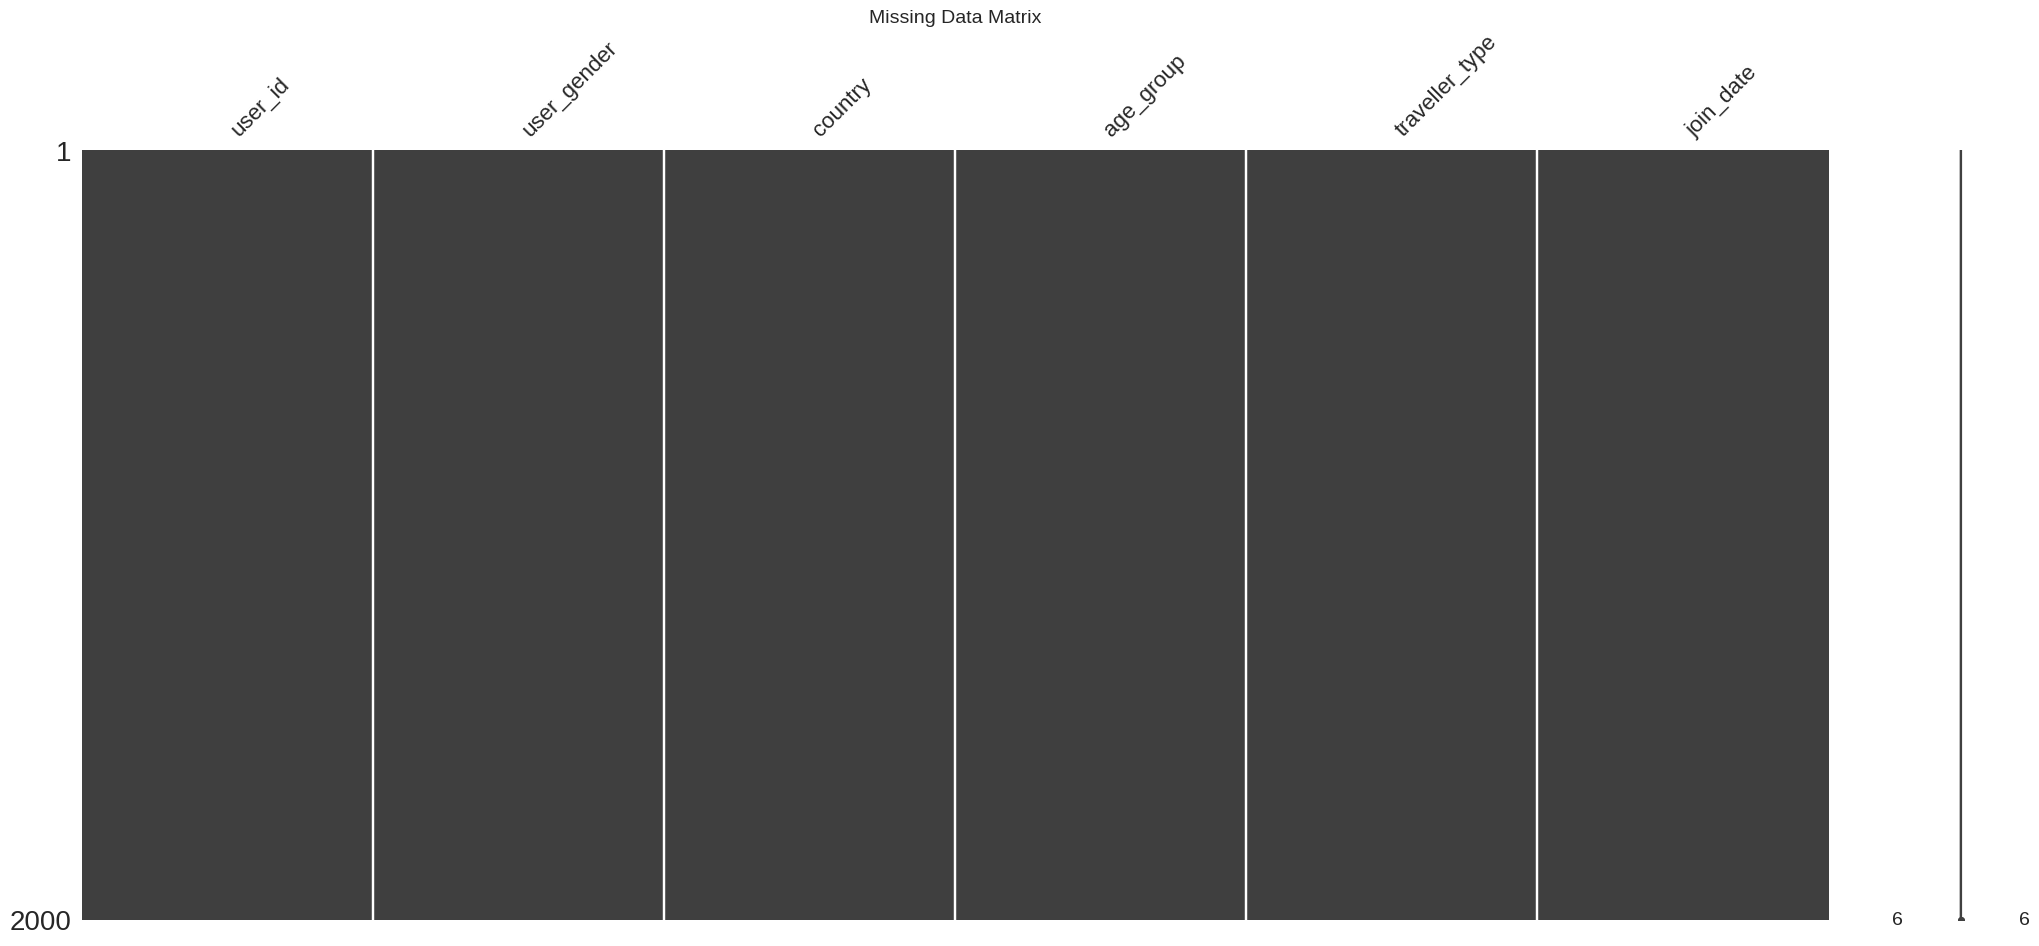


🧮 Missing Values Count
user_id           0
user_gender       0
country           0
age_group         0
traveller_type    0
join_date         0
dtype: int64
📉 Visualizing Missing Data


<Figure size 1000x500 with 0 Axes>

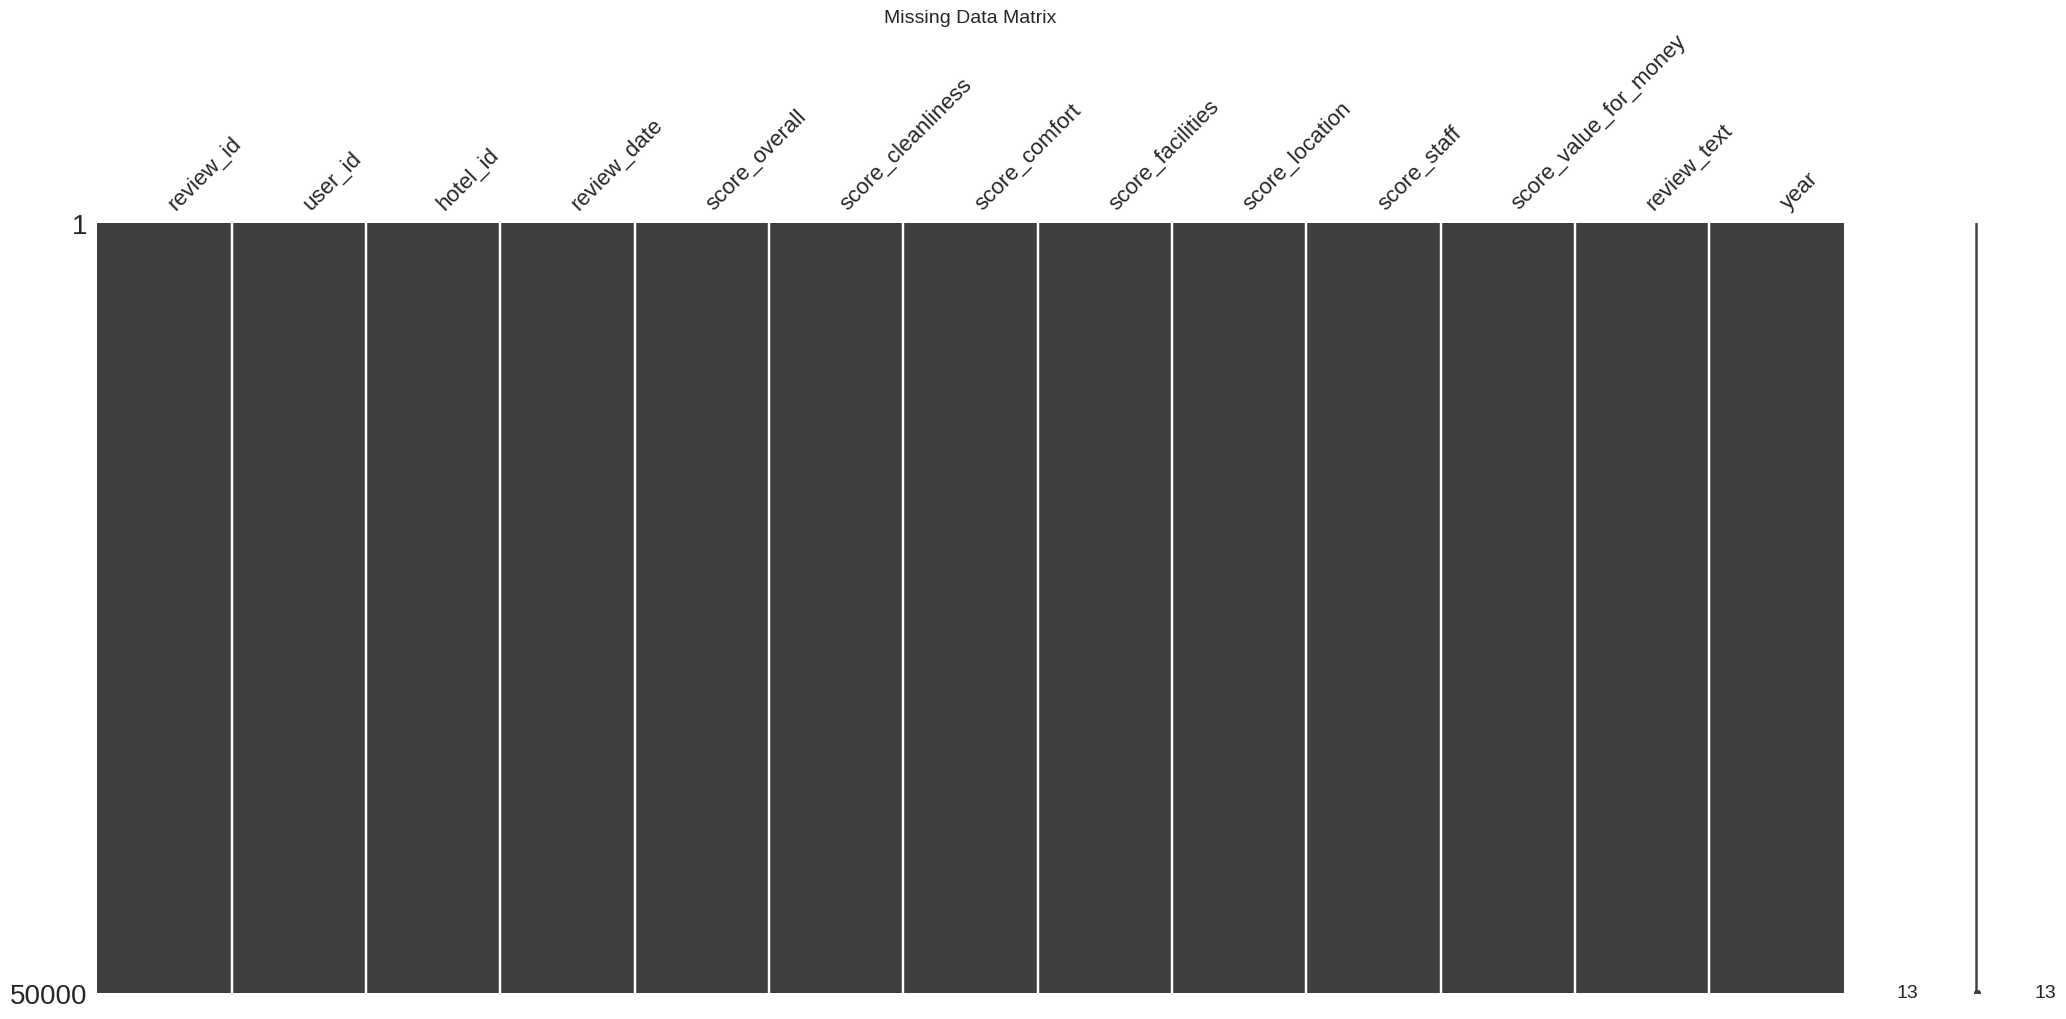


🧮 Missing Values Count
review_id                0
user_id                  0
hotel_id                 0
review_date              0
score_overall            0
score_cleanliness        0
score_comfort            0
score_facilities         0
score_location           0
score_staff              0
score_value_for_money    0
review_text              0
year                     0
dtype: int64


In [7]:
import missingno as msno
import matplotlib.pyplot as plt

# 1. Draw missing data matrix
print("📉 Visualizing Missing Data")
plt.figure(figsize=(10, 5))  # Optional: adjust size
msno.matrix(hotels_df)
plt.title("Missing Data Matrix", fontsize=14)
plt.show()
plt.close()


# 2. Print missing value counts
print("\n🧮 Missing Values Count")
print(hotels_df.isnull().sum())


# 1. Draw missing data matrix
print("📉 Visualizing Missing Data")
plt.figure(figsize=(10, 5))  # Optional: adjust size
msno.matrix(users_df)
plt.title("Missing Data Matrix", fontsize=14)
plt.show()
plt.close()

# 2. Print missing value counts
print("\n🧮 Missing Values Count")
print(users_df.isnull().sum())

# 1. Draw missing data matrix
print("📉 Visualizing Missing Data")
plt.figure(figsize=(10, 5))  # Optional: adjust size
msno.matrix(reviews_df)
plt.title("Missing Data Matrix", fontsize=14)
plt.show()
plt.close()

# 2. Print missing value counts
print("\n🧮 Missing Values Count")
print(reviews_df.isnull().sum())

In [8]:
import plotly.graph_objs as go
from plotly.subplots import make_subplots

# Prepare data
country_counts = hotels_df['country'].value_counts()
user_countries = users_df['country'].value_counts().head(15)

# Create subplot grid (1 row reserved for map or projection, if needed later)
fig = make_subplots(
    rows=2, cols=2,
    specs=[[{"type": "geo", "colspan": 2}, None],  # Optional: map (row 1)
           [{"type": "xy"}, {"type": "xy"}]],       # Row 2: bar charts
    subplot_titles=("Hotels by Country", "Users by Country")
)

# Optional: World map (can be replaced or removed if not needed)
fig.add_trace(
    go.Scattergeo(
        locations=country_counts.index,
        locationmode='country names',
        marker=dict(size=10, color='blue'),
        name="Hotel Locations"
    ),
    row=1, col=1
)

# Hotels by country (horizontal bar chart)
fig.add_trace(
    go.Bar(
        x=country_counts.values,
        y=country_counts.index,
        orientation='h',
        marker_color='lightblue',
        name='Hotels by Country'
    ),
    row=2, col=1
)

# Users by country (vertical bar chart)
fig.add_trace(
    go.Bar(
        x=user_countries.index,
        y=user_countries.values,
        marker_color='lightcoral',
        name='Users by Country'
    ),
    row=2, col=2
)

# Layout updates
fig.update_layout(
    title_text="🏨 Hotel Booking Analytics: Geographic Distribution",
    height=800,
    showlegend=False,
    geo=dict(projection_type="equirectangular")
)

# Axis titles and ticks
fig.update_xaxes(title_text="Number of Hotels", row=2, col=1)
fig.update_yaxes(title_text="Country", row=2, col=1)
fig.update_xaxes(title_text="Country", row=2, col=2, tickangle=45)
fig.update_yaxes(title_text="Number of Users", row=2, col=2)

# Show the interactive plot
fig.show()

# Insights summary
print("📊 Key Geographic Insights:")
print(f"• Hotels span {hotels_df['country'].nunique()} countries.")
print(f"• Users represent {users_df['country'].nunique()} countries.")
print(f"• Top user countries: {', '.join(user_countries.head(5).index.tolist())}")
print(f"• Wide international hotel coverage, including major global cities.")


📊 Key Geographic Insights:
• Hotels span 25 countries.
• Users represent 25 countries.
• Top user countries: United States, United Kingdom, Germany, China, France
• Wide international hotel coverage, including major global cities.


In [9]:
import plotly.graph_objs as go
from plotly.subplots import make_subplots

print("📅 TEMPORAL ANALYSIS")
print("=" * 60)

# Step 1: Prepare time-based columns
reviews_df['year_month'] = reviews_df['review_date'].dt.to_period('M')
reviews_df['month'] = reviews_df['review_date'].dt.month
reviews_df['day_of_week'] = reviews_df['review_date'].dt.day_name()
users_df['reg_year_month'] = users_df['join_date'].dt.to_period('M')

# Step 2: Create subplot structure
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        'Reviews Over Time (Monthly)', 
        'Seasonal Patterns', 
        'Day of Week Patterns', 
        'User Registration Trends'
    ],
    specs=[
        [{"secondary_y": True}, {"type": "xy"}],
        [{"type": "xy"}, {"type": "xy"}]
    ]
)

# Step 3: Monthly review trends
monthly_data = reviews_df.groupby('year_month').agg({
    'review_id': 'count',
    'score_overall': 'mean'
}).reset_index()
monthly_data['year_month_str'] = monthly_data['year_month'].astype(str)

# Review count
fig.add_trace(
    go.Scatter(
        x=monthly_data['year_month_str'],
        y=monthly_data['review_id'],
        mode='lines+markers',
        name='Review Count',
        line=dict(color='blue')
    ),
    row=1, col=1, secondary_y=False
)

# Average rating
fig.add_trace(
    go.Scatter(
        x=monthly_data['year_month_str'],
        y=monthly_data['score_overall'],
        mode='lines+markers',
        name='Average Rating',
        line=dict(color='red')
    ),
    row=1, col=1, secondary_y=True
)

# Step 4: Seasonal review counts by month
seasonal_data = reviews_df.groupby('month').agg({
    'review_id': 'count',
    'score_overall': 'mean'
}).reset_index()

fig.add_trace(
    go.Bar(
        x=seasonal_data['month'],
        y=seasonal_data['review_id'],
        name='Reviews by Month',
        marker_color='lightgreen'
    ),
    row=1, col=2
)

# Step 5: Day of the week patterns
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_data = reviews_df.groupby('day_of_week')['review_id'].count().reindex(dow_order)

fig.add_trace(
    go.Bar(
        x=dow_data.index,
        y=dow_data.values,
        name='Reviews by Day',
        marker_color='orange'
    ),
    row=2, col=1
)

# Step 6: User registration trends
reg_data = users_df.groupby('reg_year_month').size().reset_index(name='user_count')
reg_data['reg_year_month_str'] = reg_data['reg_year_month'].astype(str)

fig.add_trace(
    go.Scatter(
        x=reg_data['reg_year_month_str'],
        y=reg_data['user_count'],
        mode='lines+markers',
        name='User Registrations',
        line=dict(color='purple')
    ),
    row=2, col=2
)

# Step 7: Update layout and axes
fig.update_layout(
    title_text="📈 Hotel Booking Analytics: Temporal Patterns",
    height=800,
    showlegend=True
)

# Axes updates
fig.update_xaxes(title_text="Month-Year", tickangle=45, row=1, col=1)
fig.update_yaxes(title_text="Review Count", row=1, col=1)
fig.update_yaxes(title_text="Avg Rating", row=1, col=1, secondary_y=True)

fig.update_xaxes(title_text="Month", row=1, col=2)
fig.update_yaxes(title_text="Review Count", row=1, col=2)

fig.update_xaxes(title_text="Day of Week", tickangle=45, row=2, col=1)
fig.update_yaxes(title_text="Review Count", row=2, col=1)

fig.update_xaxes(title_text="Month-Year", tickangle=45, row=2, col=2)
fig.update_yaxes(title_text="New Users", row=2, col=2)

# Step 8: Show the figure
fig.show()

# Step 9: Key insights
print("📊 Key Temporal Insights:")
print(f"• Review volume is consistent: {reviews_df.groupby('year')['review_id'].count().std():.0f} std deviation across years")
print(f"• Peak review months: {seasonal_data.nlargest(3, 'review_id')['month'].values}")
print(f"• Most active review day: {dow_data.idxmax()}")
print(f"• Average monthly reviews: {monthly_data['review_id'].mean():.0f}")
print(f"• Rating stability over time: {monthly_data['score_overall'].std():.3f} std deviation")


📅 TEMPORAL ANALYSIS


📊 Key Temporal Insights:
• Review volume is consistent: 52 std deviation across years
• Peak review months: [7 6 5]
• Most active review day: Wednesday
• Average monthly reviews: 694
• Rating stability over time: 0.007 std deviation


In [16]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Merge users and reviews to get country info per review
merged_df = reviews_df.merge(users_df[['user_id', 'country']], on='user_id', how='left')

# Compute average "value for money" score per country
country_value = (
    merged_df.groupby('country')['score_value_for_money']
    .mean()
    .sort_values(ascending=False)
)

# Select top 3 countries
top_countries = country_value.head(3)

# Print the information
print("🏆 Top 3 Countries by Average Value for Money Score")
print(top_countries.reset_index().rename(columns={
    'country': 'Country',
    'score_value_for_money': 'Avg Value for Money'
}))
print("\n------------------------------------------------------------\n")

# Create a new figure (avoids overlap)
fig = make_subplots(rows=1, cols=1, subplot_titles=["Top 3 Countries by Value for Money"])

# Add bar chart
fig.add_trace(
    go.Bar(
        x=top_countries.index,
        y=top_countries.values,
        marker_color='lightcoral',
        name='Avg Value for Money'
    ),
    row=1, col=1
)

# Customize layout
fig.update_layout(
    height=400,
    width=700,
    title_text="Top 3 User Countries Based on Value for Money",
    showlegend=False,
    bargap=0.4
)
fig.update_xaxes(title_text="Country")
fig.update_yaxes(title_text="Average Value for Money Score", range=[0, top_countries.max() + 0.5])

# Display the figure
fig.show()


🏆 Top 3 Countries by Average Value for Money Score
     Country  Avg Value for Money
0  Singapore             8.597297
1  Argentina             8.553804
2      Egypt             8.540341

------------------------------------------------------------



🏙 Best City per Traveler Type:

        city traveller_type  score_overall
0      Dubai         Family       9.214381
1  Amsterdam           Solo       9.108454
2  Amsterdam         Couple       9.096989
3      Dubai       Business       8.965668


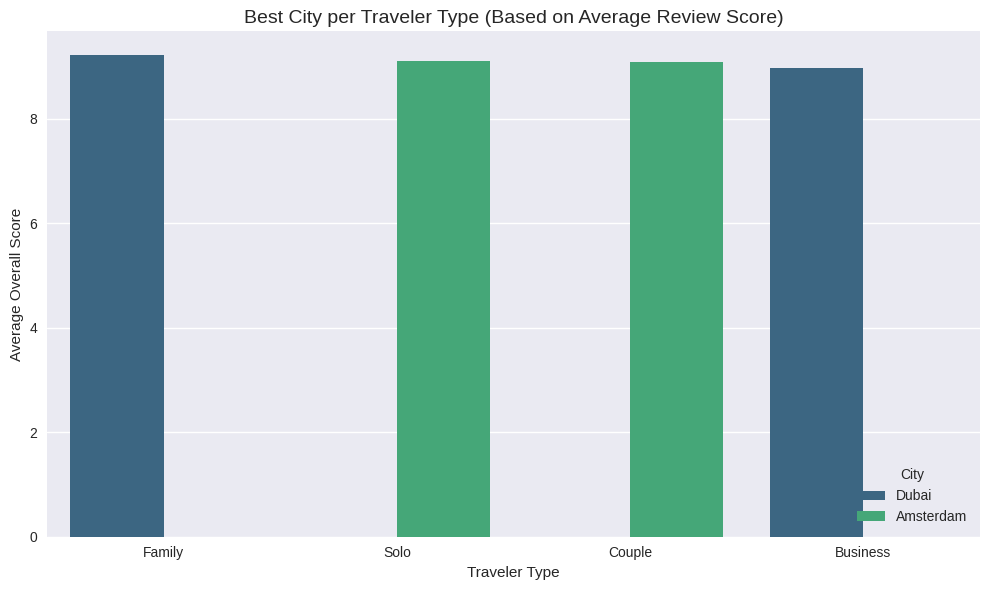

In [17]:
merged_df = (
    reviews_df
    .merge(users_df, on="user_id", how="left")
    .merge(hotels_df, on="hotel_id", how="left")
)

# ------------------------------------------------------------
# ⿤ Compute average review score per (city, traveler_type)
# ------------------------------------------------------------
city_traveler_avg = (
    merged_df.groupby(["city", "traveller_type"])["score_overall"]
    .mean()
    .reset_index()
)

# ------------------------------------------------------------
# ⿥ Find the best city for each traveler type
# ------------------------------------------------------------
best_city_per_type = (
    city_traveler_avg.loc[
        city_traveler_avg.groupby("traveller_type")["score_overall"].idxmax()
    ]
    .sort_values("score_overall", ascending=False)
    .reset_index(drop=True)
)
print("🏙 Best City per Traveler Type:\n")
print(best_city_per_type)

# ------------------------------------------------------------
# ⿦ Visualization - Which city performs best for each traveler type?
# ------------------------------------------------------------
plt.figure(figsize=(10,6))
sns.barplot(
    data=best_city_per_type,
    x="traveller_type",
    y="score_overall",
    hue="city",
    palette="viridis"
)

plt.title("Best City per Traveler Type (Based on Average Review Score)", fontsize=14)
plt.xlabel("Traveler Type")
plt.ylabel("Average Overall Score")
plt.legend(title="City", loc="lower right")
plt.tight_layout()
plt.show()

In [18]:
import plotly.graph_objects as go

# ------------------------------------------------------------
# ✅ Data Prep (same as your version)
# ------------------------------------------------------------
merged_df = (
    reviews_df
    .merge(users_df, on="user_id", how="left")
    .merge(hotels_df, on="hotel_id", how="left")
)

# Compute average overall score per (city, traveler_type)
city_traveler_avg = (
    merged_df.groupby(["city", "traveller_type"])["score_overall"]
    .mean()
    .reset_index()
)

# Find the best city for each traveler type
best_city_per_type = (
    city_traveler_avg.loc[
        city_traveler_avg.groupby("traveller_type")["score_overall"].idxmax()
    ]
    .sort_values("score_overall", ascending=False)
    .reset_index(drop=True)
)

# Display table
print("🏙 Best City per Traveler Type:\n")
print(best_city_per_type.rename(columns={
    "traveller_type": "Traveler Type",
    "city": "Best City",
    "score_overall": "Avg Overall Score"
}).to_string(index=False))
print("\n------------------------------------------------------------\n")

# ------------------------------------------------------------
# 📈 Visualization - Plotly style (same look as previous graphs)
# ------------------------------------------------------------
fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=best_city_per_type["traveller_type"],
        y=best_city_per_type["score_overall"],
        text=best_city_per_type["city"],
        textposition="auto",
        marker_color="lightcoral",
        name="Best City"
    )
)

# Layout settings for consistency
fig.update_layout(
    title="Best City per Traveler Type (Based on Average Review Score)",
    xaxis_title="Traveler Type",
    yaxis_title="Average Overall Score",
    height=500,
    width=800,
    bargap=0.4,
    showlegend=False,
    title_x=0.5
)

fig.show()


🏙 Best City per Traveler Type:

Best City Traveler Type  Avg Overall Score
    Dubai        Family           9.214381
Amsterdam          Solo           9.108454
Amsterdam        Couple           9.096989
    Dubai      Business           8.965668

------------------------------------------------------------



In [20]:
hotels_df['country_group'] = None
hotels_df.head()

,hotel_id,hotel_name,city,country,star_rating,lat,lon,cleanliness_base,comfort_base,facilities_base,location_base,staff_base,value_for_money_base,country_group
0,1,The Azure Tower,New York,United States,5,40.7580,-73.9855,9.1,8.8,8.9,9.5,8.6,8.0,None
1,2,The Royal Compass,London,United Kingdom,5,51.5072,-0.1276,9.0,9.2,8.8,9.4,9.0,7.9,None
2,3,L'Étoile Palace,Paris,France,5,48.8566,2.3522,8.8,9.4,8.7,9.6,9.3,8.1,None
3,4,Kyo-to Grand,Tokyo,Japan,5,35.6895,139.6917,9.6,9.0,9.3,8.5,9.5,8.2,None
4,5,The Golden Oasis,Dubai,United Arab Emirates,5,25.2769,55.2962,9.3,9.5,9.6,8.9,9.4,8.5,None


In [21]:
# Define country → region mapping
country_to_group = {
    # North America
    'United States': 'North_America',
    'Canada': 'North_America',

    # Western Europe
    'Germany': 'Western_Europe',
    'France': 'Western_Europe',
    'United Kingdom': 'Western_Europe',
    'Netherlands': 'Western_Europe',
    'Spain': 'Western_Europe',
    'Italy': 'Western_Europe',

    # Eastern Europe
    'Russia': 'Eastern_Europe',

    # East Asia
    'China': 'East_Asia',
    'Japan': 'East_Asia',
    'South Korea': 'East_Asia',

    # Southeast Asia
    'Thailand': 'Southeast_Asia',
    'Singapore': 'Southeast_Asia',

    # Middle East
    'United Arab Emirates': 'Middle_East',
    'Turkey': 'Middle_East',

    # Africa
    'Egypt': 'Africa',
    'Nigeria': 'Africa',
    'South Africa': 'Africa',

    # Oceania
    'Australia': 'Oceania',
    'New Zealand': 'Oceania',

    # South America
    'Brazil': 'South_America',
    'Argentina': 'South_America',

    # South Asia
    'India': 'South_Asia',

    # North America (Mexico)
    'Mexico': 'North_America_Mexico'
}

# Fill based on mapping
hotels_df['country_group'] = hotels_df['country'].map(country_to_group)

# Verify the result
print(hotels_df[['country', 'country_group']].head(20))


                 country         country_group
0          United States         North_America
1         United Kingdom        Western_Europe
2                 France        Western_Europe
3                  Japan             East_Asia
4   United Arab Emirates           Middle_East
5              Singapore        Southeast_Asia
6              Australia               Oceania
7                 Brazil         South_America
8                Germany        Western_Europe
9                 Canada         North_America
10                 China             East_Asia
11                Mexico  North_America_Mexico
12                 India            South_Asia
13                 Italy        Western_Europe
14          South Africa                Africa
15           South Korea             East_Asia
16                Russia        Eastern_Europe
17                 Egypt                Africa
18                 Spain        Western_Europe
19              Thailand        Southeast_Asia


In [22]:
hotels_df.head()

,hotel_id,hotel_name,city,country,star_rating,lat,lon,cleanliness_base,comfort_base,facilities_base,location_base,staff_base,value_for_money_base,country_group
0,1,The Azure Tower,New York,United States,5,40.7580,-73.9855,9.1,8.8,8.9,9.5,8.6,8.0,North_America
1,2,The Royal Compass,London,United Kingdom,5,51.5072,-0.1276,9.0,9.2,8.8,9.4,9.0,7.9,Western_Europe
2,3,L'Étoile Palace,Paris,France,5,48.8566,2.3522,8.8,9.4,8.7,9.6,9.3,8.1,Western_Europe
3,4,Kyo-to Grand,Tokyo,Japan,5,35.6895,139.6917,9.6,9.0,9.3,8.5,9.5,8.2,East_Asia
4,5,The Golden Oasis,Dubai,United Arab Emirates,5,25.2769,55.2962,9.3,9.5,9.6,8.9,9.4,8.5,Middle_East


In [28]:
# # --- Merge reviews with users (user-level features)
# merged_df = reviews_df.merge(
#     users_df[['user_id', 'user_gender', 'age_group', 'traveller_type']],
#     on='user_id', how='left'
# )

# # --- Merge with hotels (hotel-level features)
# merged_df = merged_df.merge(
#     hotels_df[['hotel_id', 'hotel_name', 'city', 'country', 'star_rating',
#                'cleanliness_base', 'comfort_base', 'facilities_base',
#                'location_base', 'staff_base', 'value_for_money_base', 'country_group']],
#     on='hotel_id', how='left'
# )

# # --- Add quality-based features
# merged_df['quality_diff_overall'] = merged_df['score_overall'] - merged_df['star_rating']
# merged_df['quality_ratio_value_for_money'] = (
#     merged_df['score_value_for_money'] / merged_df['value_for_money_base']
# )

merged_df = reviews_df.merge(users_df, on="user_id", how="left").merge(hotels_df, on="hotel_id", how="left")


In [29]:
available_cols = merged_df.columns.tolist()
print("Available columns:", available_cols[:20], "...")  # Print first 20

# Build feature list based on what exists
feature_list = []

# Add star_rating if it varies by review (check first)
if 'star_rating' in merged_df.columns:
    star_variance = merged_df.groupby('hotel_id')['star_rating'].var().mean() if 'hotel_id' in merged_df.columns else 1
    if star_variance > 0.01:
        feature_list.append('star_rating')
    else:
        print("⚠️  Skipping 'star_rating' - it's hotel-level (no variance)")

# ONLY use review-level scores (these vary per review)
review_score_cols = ['score_overall', 'score_value_for_money', 'score_cleanliness', 
                     'score_comfort', 'score_facilities', 'score_staff', 'score_location']
for col in review_score_cols:
    if col in merged_df.columns:
        feature_list.append(col)
        
# User features (these are review/user specific)
user_cols = ['user_gender', 'age_group', 'traveller_type']
for col in user_cols:
    if col in merged_df.columns:
        feature_list.append(col)

# If you have review text features, sentiment, etc., add them too
other_possible_cols = ['review_length', 'sentiment_score', 'days_since_stay']
for col in other_possible_cols:
    if col in merged_df.columns:
        feature_list.append(col)
if 'location_base' in merged_df.columns:
    feature_list.append('location_base')

print(f"\n✅ Using {len(feature_list)} features (review-level + user-level only):")
print(feature_list)

X = merged_df[feature_list]

y = merged_df['country_group']

print("Initial feature shape:", X.shape)
print("Target distribution:\n", y.value_counts())

# ========================================
# OPTIONAL: If you want to use hotel-level scores WITHOUT leakage
# ========================================
# Create "relative to review score" features
# This removes hotel identity while keeping quality relationships

hotel_level_cols = ['cleanliness_base', 'comfort_base', 'facilities_base', 
                    'staff_base', 'value_for_money_base']

for hotel_col in hotel_level_cols:
    # Find corresponding review-level score
    review_col = hotel_col.replace('_base', '').replace('value_for_money', 'value_for_money')
    review_col = f'score_{review_col}' if not review_col.startswith('score_') else review_col
    
    if hotel_col in merged_df.columns and review_col in merged_df.columns:
        # Create: "How much did this review differ from hotel average?"
        X[f'{hotel_col}_deviation'] = merged_df[review_col] - merged_df[hotel_col]
        print(f"✓ Created {hotel_col}_deviation")

print(f"\nFinal feature count: {X.shape[1]}")

Available columns: ['review_id', 'user_id', 'hotel_id', 'review_date', 'score_overall', 'score_cleanliness', 'score_comfort', 'score_facilities', 'score_location', 'score_staff', 'score_value_for_money', 'review_text', 'year', 'year_month', 'month', 'day_of_week', 'user_gender', 'country_x', 'age_group', 'traveller_type'] ...
⚠️  Skipping 'star_rating' - it's hotel-level (no variance)

✅ Using 11 features (review-level + user-level only):
['score_overall', 'score_value_for_money', 'score_cleanliness', 'score_comfort', 'score_facilities', 'score_staff', 'score_location', 'user_gender', 'age_group', 'traveller_type', 'location_base']
Initial feature shape: (50000, 11)
Target distribution:
 country_group
Western_Europe          11876
Africa                   6132
East_Asia                6082
Southeast_Asia           4070
Oceania                  4014
Middle_East              3983
North_America            3962
South_America            3918
North_America_Mexico     2004
South_Asia         

In [30]:
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [31]:
import pandas as pd

# Make a copy to avoid modifying original
X_encoded = pd.get_dummies(
    X,
    columns=['user_gender', 'age_group', 'traveller_type'],  # your categorical features
    drop_first=True  # avoid dummy variable trap
)

In [32]:
print("\n" + "="*60)
print("LEAKAGE DETECTION")
print("="*60)

df_temp = X_encoded.copy()
df_temp["target"] = y_encoded
corr = df_temp.corr(numeric_only=True)["target"].abs().sort_values(ascending=False)

print("\nCorrelation with target (country_group):")
print(corr)

# Flag high correlations
high_corr_features = corr[(corr > 0.5) & (corr.index != "target")]
if len(high_corr_features) > 0:
    print("\n⚠️  WARNING: Potential leakage detected!")
    print("Features with correlation > 0.5:")
    print(high_corr_features)
    print("\nThese features may directly encode the target.")
else:
    print("\n✅ No obvious leakage detected (all correlations < 0.5)")

# Check moderate correlations (informative but not leakage)
moderate_corr = corr[(corr >= 0.2) & (corr <= 0.5) & (corr.index != "target")]
if len(moderate_corr) > 0:
    print("\nℹ️  Features with moderate correlation (0.2-0.5):")
    print(moderate_corr)

# ========================================
# ADDITIONAL DIAGNOSTICS: Check if scores are hotel-level or review-level
# ========================================
print("\n" + "="*60)
print("DATA STRUCTURE ANALYSIS")
print("="*60)

# Check if score features vary within hotels
print("\nChecking if scores vary per hotel (review-level) or are constant (hotel-level):")
score_cols_to_check = ['cleanliness_base', 'comfort_base', 'facilities_base', 
                       'staff_base', 'value_for_money_base', 'score_overall']

for col in score_cols_to_check:
    if col in merged_df.columns and 'hotel_id' in merged_df.columns:
        # Check variance within hotels
        within_hotel_variance = merged_df.groupby('hotel_id')[col].var().mean()
        total_variance = merged_df[col].var()
        
        print(f"\n{col}:")
        print(f"  Within-hotel variance: {within_hotel_variance:.6f}")
        print(f"  Total variance: {total_variance:.6f}")
        
        if within_hotel_variance < 0.01:  # Essentially no variation
            print(f"  ⚠️  HOTEL-LEVEL feature (same value for all reviews of a hotel)")
        else:
            print(f"  ✓ REVIEW-LEVEL feature (varies by review)")

# Check if hotels are country-specific
print("\n" + "="*60)
print("HOTEL DISTRIBUTION ANALYSIS")
print("="*60)

if 'hotel_id' in merged_df.columns:
    hotel_countries = merged_df.groupby('hotel_id')['country_group'].nunique()
    hotels_in_multiple_countries = (hotel_countries > 1).sum()
    total_hotels = len(hotel_countries)
    
    print(f"\nTotal unique hotels: {total_hotels}")
    print(f"Hotels appearing in multiple countries: {hotels_in_multiple_countries}")
    
    if hotels_in_multiple_countries == 0:
        print("\n🚨 CRITICAL ISSUE: Each hotel belongs to exactly ONE country!")
        print("This means hotel-level features (like aggregated scores) will")
        print("perfectly encode the country, causing leakage.")
        print("\n💡 SOLUTION: Use only REVIEW-LEVEL features, not hotel aggregates.")


LEAKAGE DETECTION

Correlation with target (country_group):
target                            1.000000
location_base                     0.519075
score_location                    0.302788
score_overall                     0.160780
score_comfort                     0.061909
comfort_base_deviation            0.032839
value_for_money_base_deviation    0.024690
score_value_for_money             0.021236
score_facilities                  0.018529
staff_base_deviation              0.017317
score_cleanliness                 0.016984
score_staff                       0.010192
user_gender_Male                  0.008387
traveller_type_Family             0.006814
cleanliness_base_deviation        0.005405
traveller_type_Solo               0.004933
user_gender_Other                 0.004295
age_group_35-44                   0.003781
age_group_45-54                   0.003518
traveller_type_Couple             0.002906
age_group_55+                     0.002902
age_group_25-34                   0.

In [34]:
X_encoded.drop(columns=['location_base'], inplace=True)


   score_overall  score_value_for_money  score_cleanliness  score_comfort  \
0            8.7                    8.7                8.6            8.7   
1            9.1                    8.6               10.0            9.1   
2            8.8                    8.6                9.7            8.8   
3            8.9                    8.3                9.0            8.8   
4            9.1                    8.9                8.9            9.5   

   score_facilities  score_staff  score_location  cleanliness_base_deviation  \
0               8.5          8.8             9.0                        -0.5   
1               9.0          9.4             8.6                         0.4   
2               8.3          8.1             8.7                         0.9   
3               8.5          9.1             9.6                        -0.2   
4               9.3          9.4             8.3                        -0.2   

   comfort_base_deviation  facilities_base_deviation  ..

In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"\nTrain size: {len(X_train)}, Test size: {len(X_test)}")

# ========================================
# STEP 6: Scale Numerical Features (fit on train only!)
# ========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Train size: 40000, Test size: 10000


In [73]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import joblib


TRAINING RANDOM FOREST

MODEL PERFORMANCE

TRAIN Accuracy: 0.7527
TEST Accuracy:  0.6553
Difference:     0.0974

✅ Model performance looks reasonable!

DETAILED CLASSIFICATION REPORT
                      precision    recall  f1-score   support

              Africa       0.93      0.39      0.55      1226
           East_Asia       0.82      0.68      0.74      1216
      Eastern_Europe       0.26      0.90      0.41       394
         Middle_East       0.93      0.64      0.76       797
       North_America       0.79      0.76      0.77       792
North_America_Mexico       0.49      0.97      0.65       401
             Oceania       0.78      0.42      0.55       803
       South_America       0.62      0.56      0.59       784
          South_Asia       0.39      0.68      0.50       398
      Southeast_Asia       0.62      0.76      0.68       814
      Western_Europe       0.79      0.73      0.76      2375

            accuracy                           0.66     10000
        

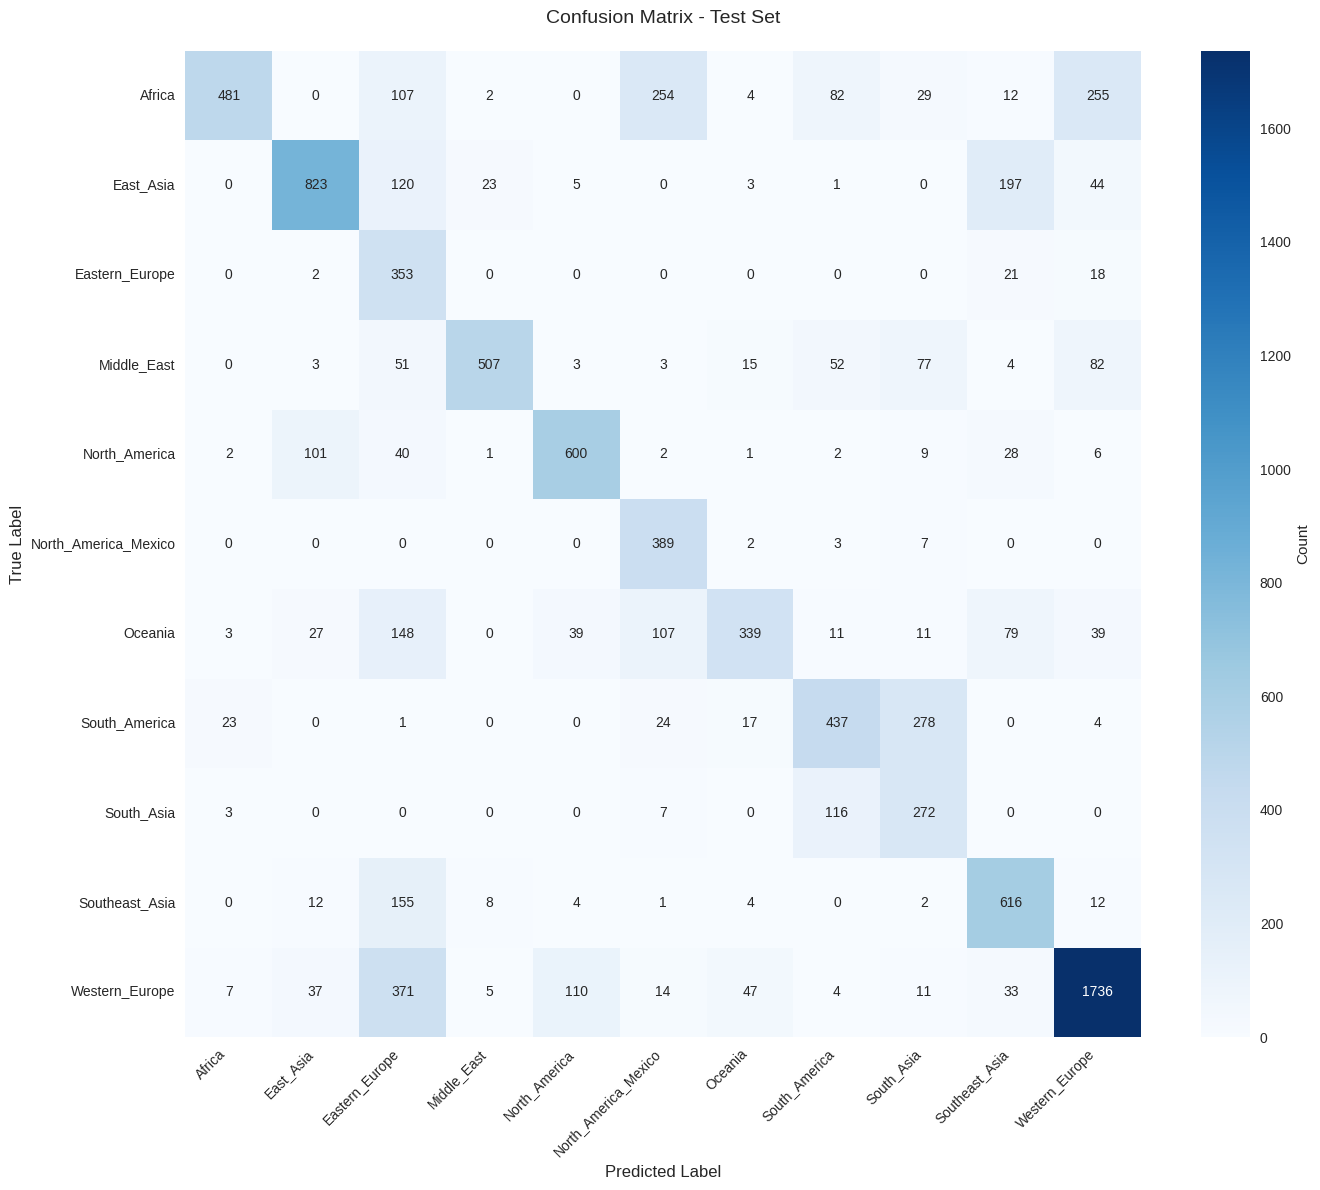


FEATURE IMPORTANCE ANALYSIS

Top 15 Most Important Features:
facilities_base_deviation         0.134682
score_facilities                  0.127260
score_overall                     0.088883
comfort_base_deviation            0.082998
score_location                    0.080853
score_comfort                     0.080071
staff_base_deviation              0.069912
score_cleanliness                 0.067571
score_staff                       0.066067
cleanliness_base_deviation        0.063251
score_value_for_money             0.062383
value_for_money_base_deviation    0.049675
traveller_type_Family             0.006734
traveller_type_Couple             0.005401
user_gender_Male                  0.003701
dtype: float64


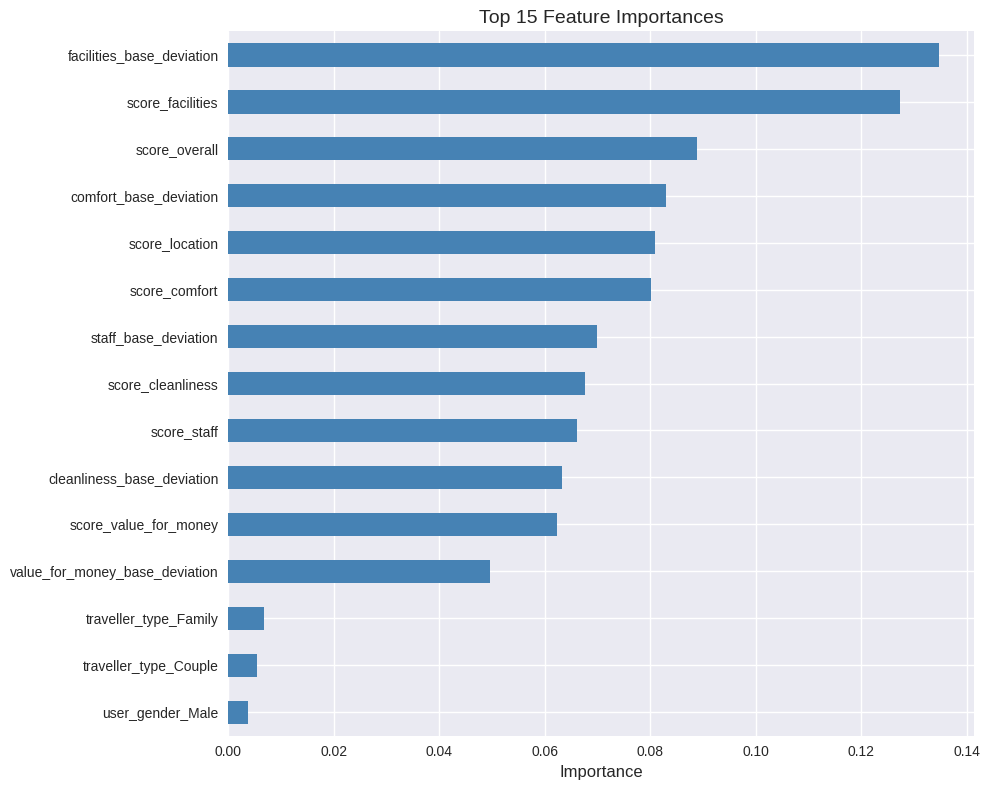


DIAGNOSTIC SUMMARY

✓ Number of features: 21
✓ Number of classes: 11
✓ Baseline accuracy (random guess): 0.0909
✓ Your model test accuracy: 0.6553
✓ Improvement over baseline: 0.5644

✅ Model diagnostics look good!


In [74]:
print("\n" + "="*60)
print("TRAINING RANDOM FOREST")
print("="*60)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,              # Limit depth to prevent overfitting
    min_samples_split=50,      # Require more samples to split
    min_samples_leaf=20,       # Require more samples in leaves
    max_features='sqrt',       # Only consider sqrt(n) features per split
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf.fit(X_train_scaled, y_train)

# ========================================
# STEP 8: Evaluate Model
# ========================================
y_pred_train = rf.predict(X_train_scaled)
y_pred_test = rf.predict(X_test_scaled)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print("\n" + "="*60)
print("MODEL PERFORMANCE")
print("="*60)

print(f"\nTRAIN Accuracy: {train_acc:.4f}")
print(f"TEST Accuracy:  {test_acc:.4f}")
print(f"Difference:     {train_acc - test_acc:.4f}")

# Interpret results
if test_acc > 0.95:
    print("\n⚠️  SUSPICIOUSLY HIGH TEST ACCURACY!")
    print("This suggests DATA LEAKAGE - features directly encode the target.")
    print("Review the correlation analysis above.")
elif train_acc - test_acc > 0.15:
    print("\n⚠️  OVERFITTING DETECTED!")
    print("Model memorizes training data but generalizes poorly.")
    print("Consider: more regularization, fewer features, or more data.")
elif test_acc < 0.25:
    print("\nℹ️  Low accuracy (close to random guessing for 11 classes).")
    print("Features may not contain strong signals for prediction.")
else:
    print("\n✅ Model performance looks reasonable!")

print("\n" + "="*60)
print("DETAILED CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred_test, target_names=le.classes_, zero_division=0))

# ========================================
# STEP 9: Confusion Matrix
# ========================================
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'Count'})
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.title('Confusion Matrix - Test Set', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ========================================
# STEP 10: Feature Importance Analysis
# ========================================
print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

feat_importances = pd.Series(
    rf.feature_importances_, 
    index=X_train.columns
).sort_values(ascending=False)

print("\nTop 15 Most Important Features:")
print(feat_importances.head(15))

plt.figure(figsize=(10, 8))
feat_importances.head(15).plot(kind='barh', color='steelblue')
plt.xlabel('Importance', fontsize=12)
plt.title('Top 15 Feature Importances', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ========================================
# STEP 11: Diagnostic Summary
# ========================================
print("\n" + "="*60)
print("DIAGNOSTIC SUMMARY")
print("="*60)

print(f"\n✓ Number of features: {X_encoded.shape[1]}")
print(f"✓ Number of classes: {len(le.classes_)}")
print(f"✓ Baseline accuracy (random guess): {1/len(le.classes_):.4f}")
print(f"✓ Your model test accuracy: {test_acc:.4f}")
print(f"✓ Improvement over baseline: {(test_acc - 1/len(le.classes_)):.4f}")

if test_acc > 0.90:
    print("\n🚨 ACTION REQUIRED: Investigate leakage!")
    print("   Check if any score features are aggregated by country/region.")
elif train_acc > test_acc + 0.15:
    print("\n⚡ Suggestion: Try cross-validation or more regularization")
else:
    print("\n✅ Model diagnostics look good!")

In [75]:
print("\n" + "="*60)
print("FINAL FEATURES USED IN MODEL")
print("="*60)
print(f"\nTotal features: {len(X_encoded.columns)}")
print("\nAll features:")
for i, col in enumerate(X_encoded.columns, 1):
    print(f"{i:2d}. {col}")


FINAL FEATURES USED IN MODEL

Total features: 21

All features:
 1. score_overall
 2. score_value_for_money
 3. score_cleanliness
 4. score_comfort
 5. score_facilities
 6. score_staff
 7. score_location
 8. cleanliness_base_deviation
 9. comfort_base_deviation
10. facilities_base_deviation
11. staff_base_deviation
12. value_for_money_base_deviation
13. user_gender_Male
14. user_gender_Other
15. age_group_25-34
16. age_group_35-44
17. age_group_45-54
18. age_group_55+
19. traveller_type_Couple
20. traveller_type_Family
21. traveller_type_Solo


In [76]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
from lime import lime_tabular

In [77]:
# ===========================================
# Prepare DataFrames
# ===========================================
X_train_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_df  = pd.DataFrame(X_test_scaled, columns=X_train.columns)


🔍 SHAP EXPLANATIONS (Multiclass Compatible)
Computing SHAP values...
✅ Done!

🌍 GLOBAL SHAP SUMMARY (Per Class)

📊 Plotting SHAP summary for class: Africa


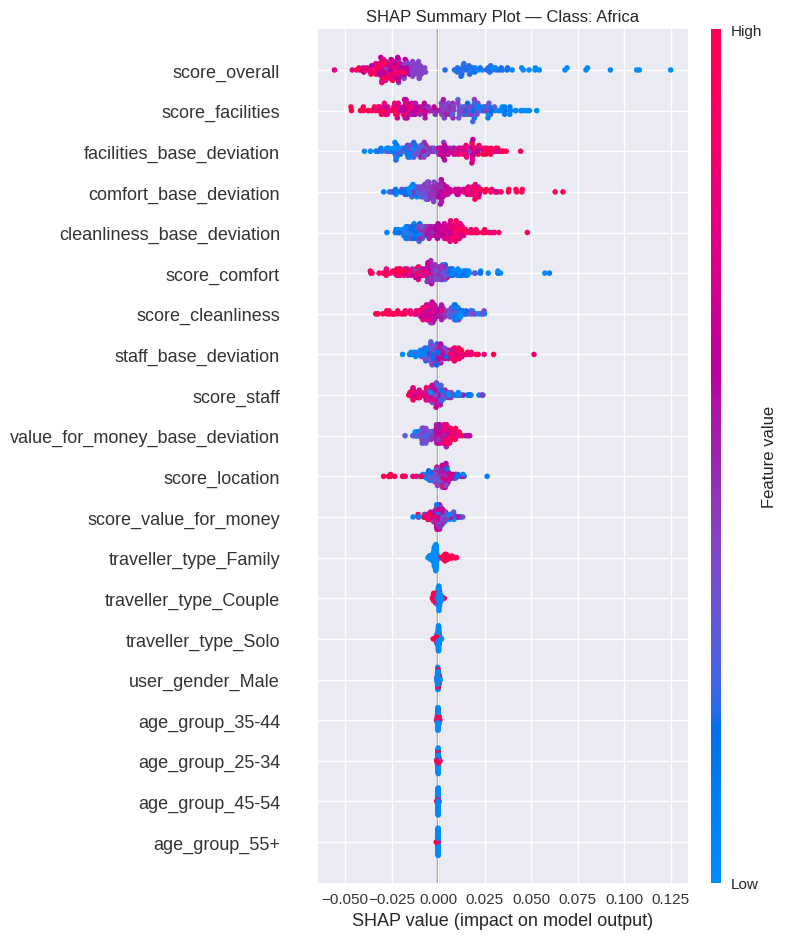


📊 Plotting SHAP summary for class: East_Asia


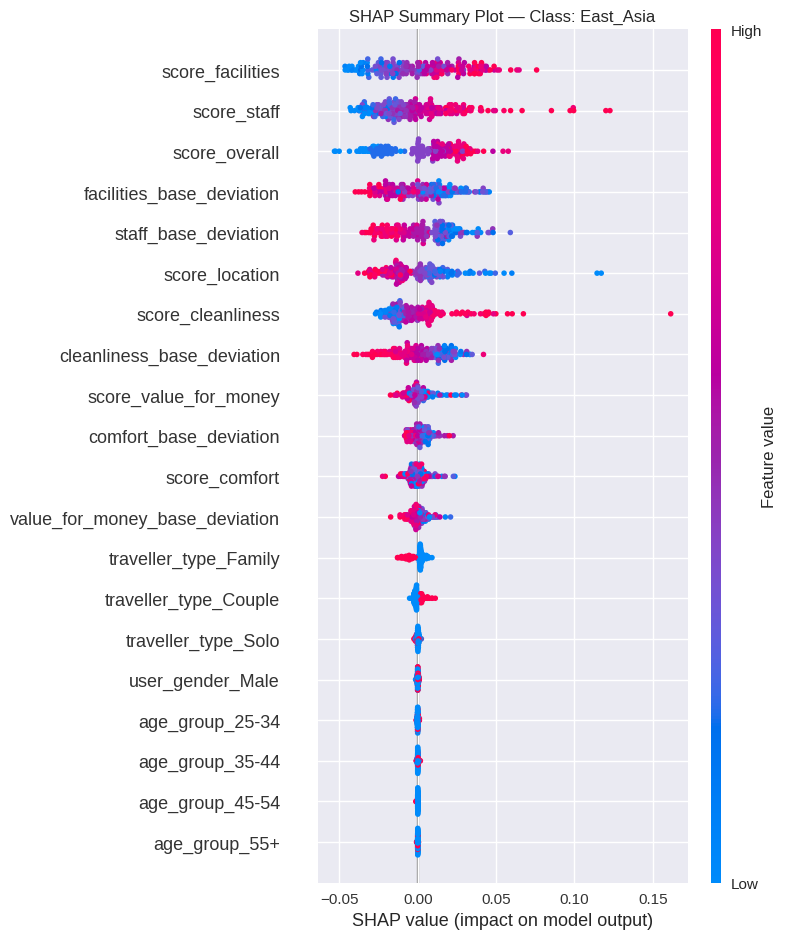


📊 Plotting SHAP summary for class: Eastern_Europe


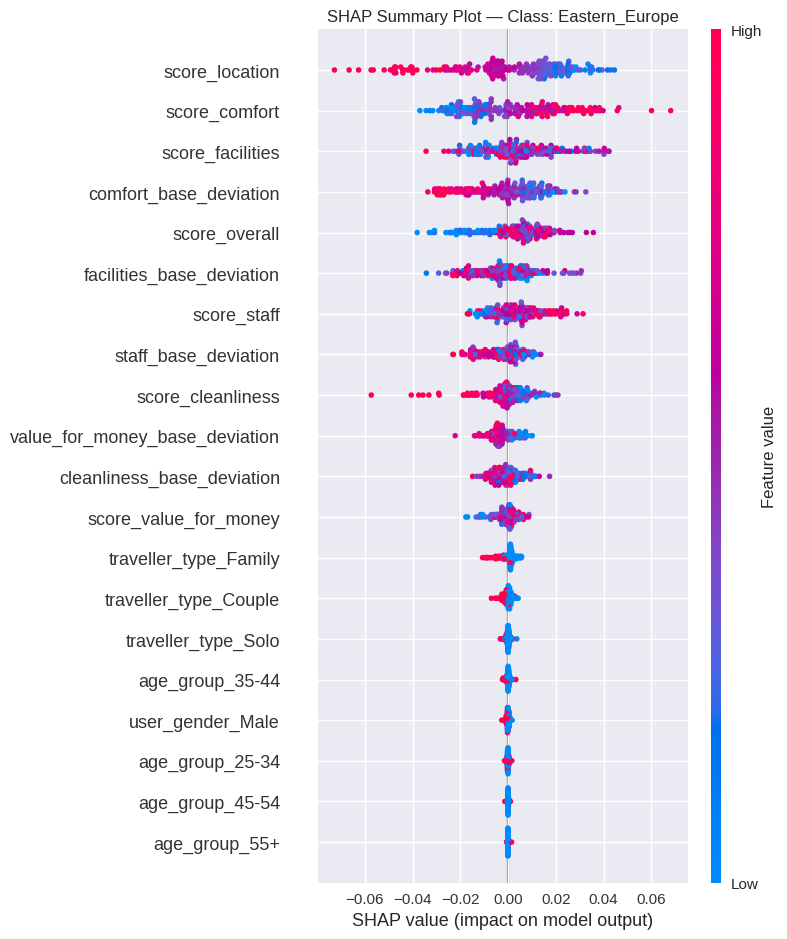


📊 Plotting SHAP summary for class: Middle_East


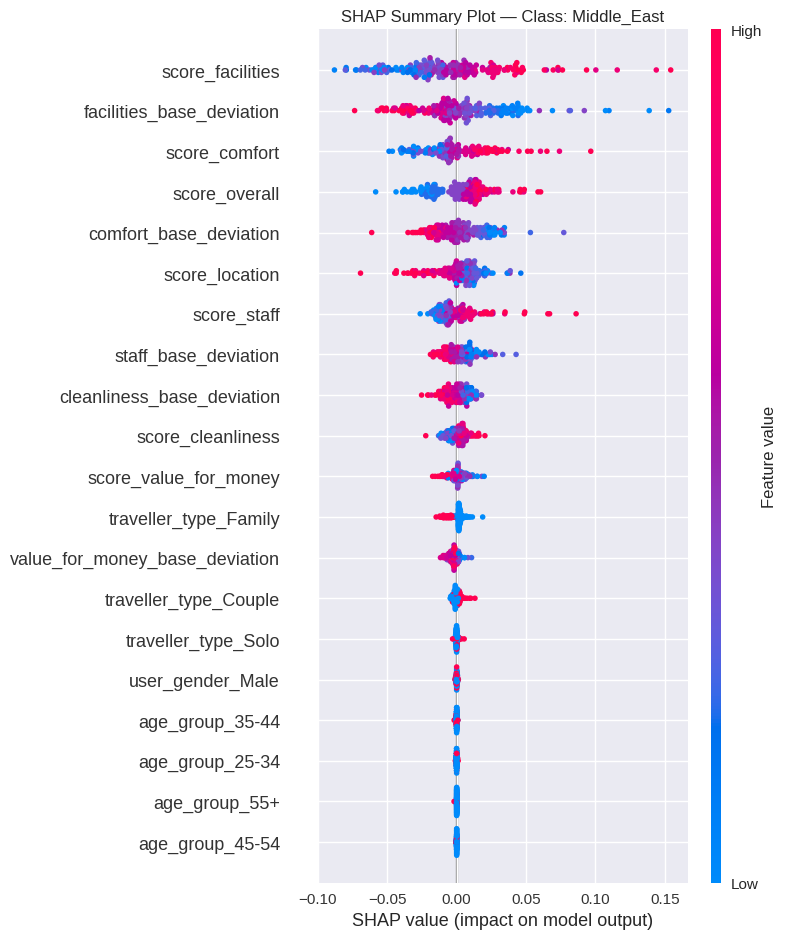


📊 Plotting SHAP summary for class: North_America


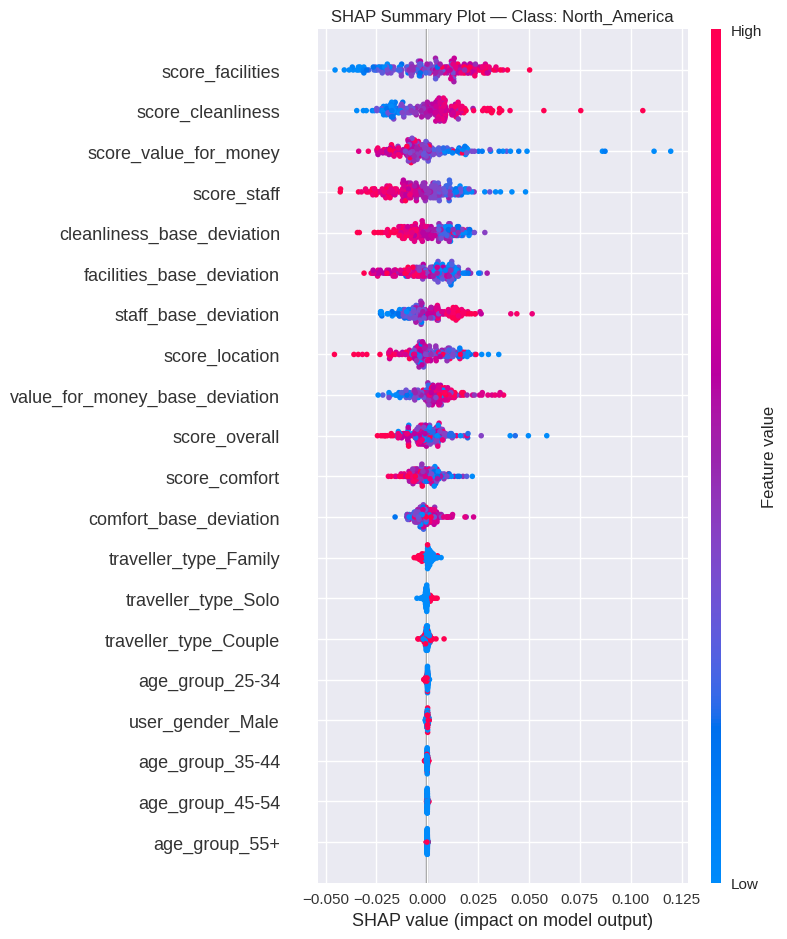


📊 Plotting SHAP summary for class: North_America_Mexico


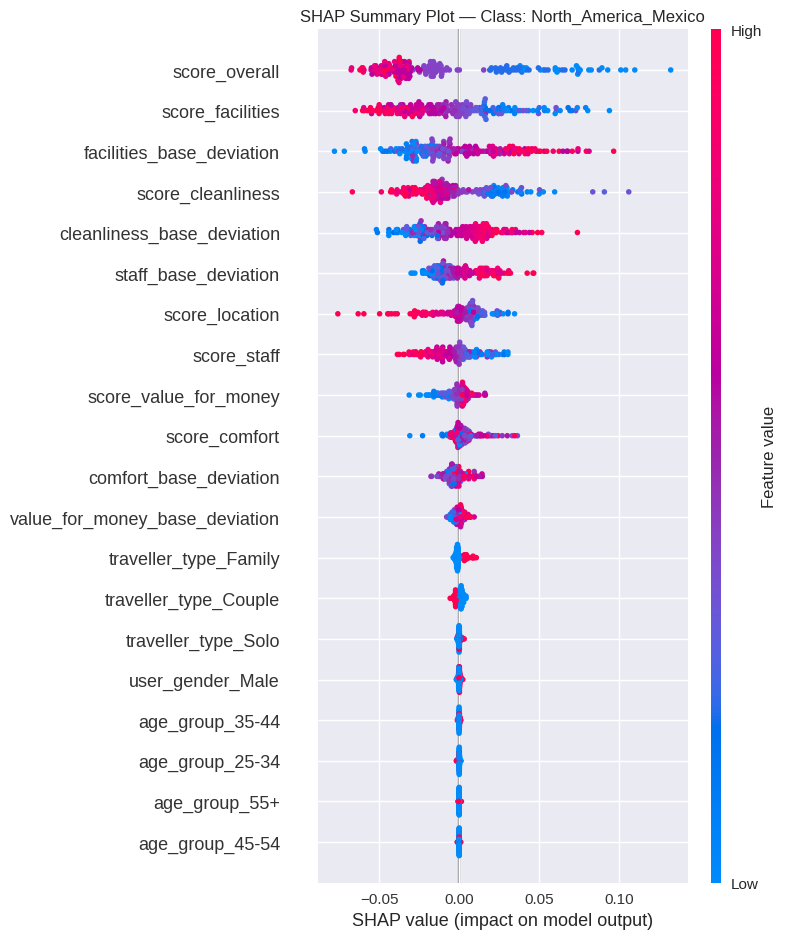


📊 Plotting SHAP summary for class: Oceania


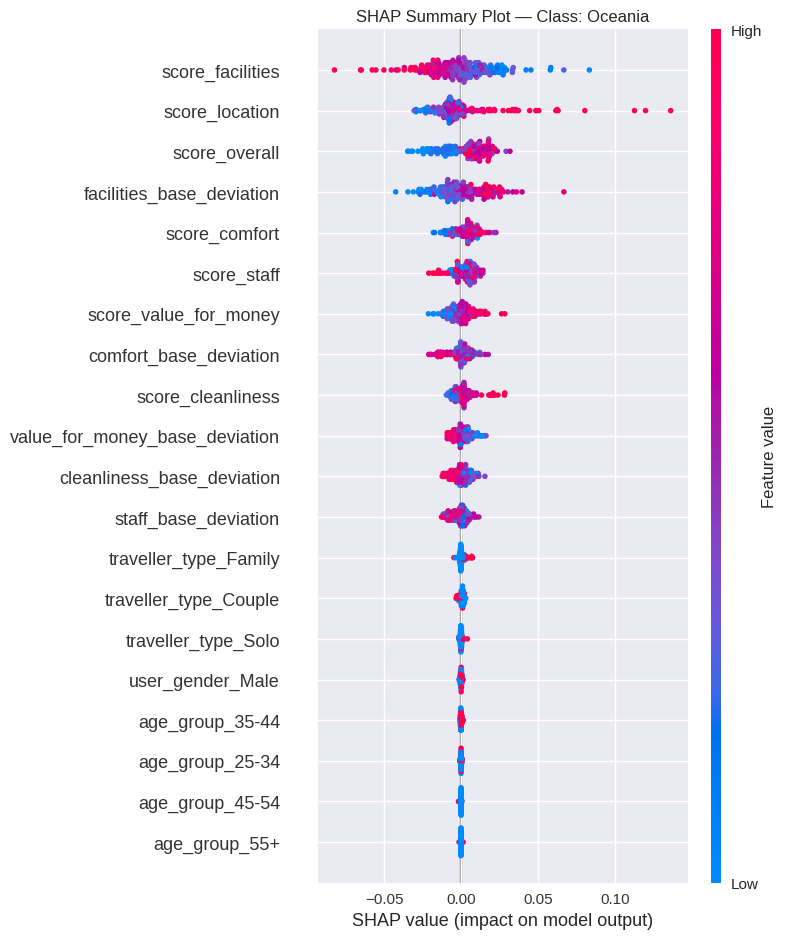


📊 Plotting SHAP summary for class: South_America


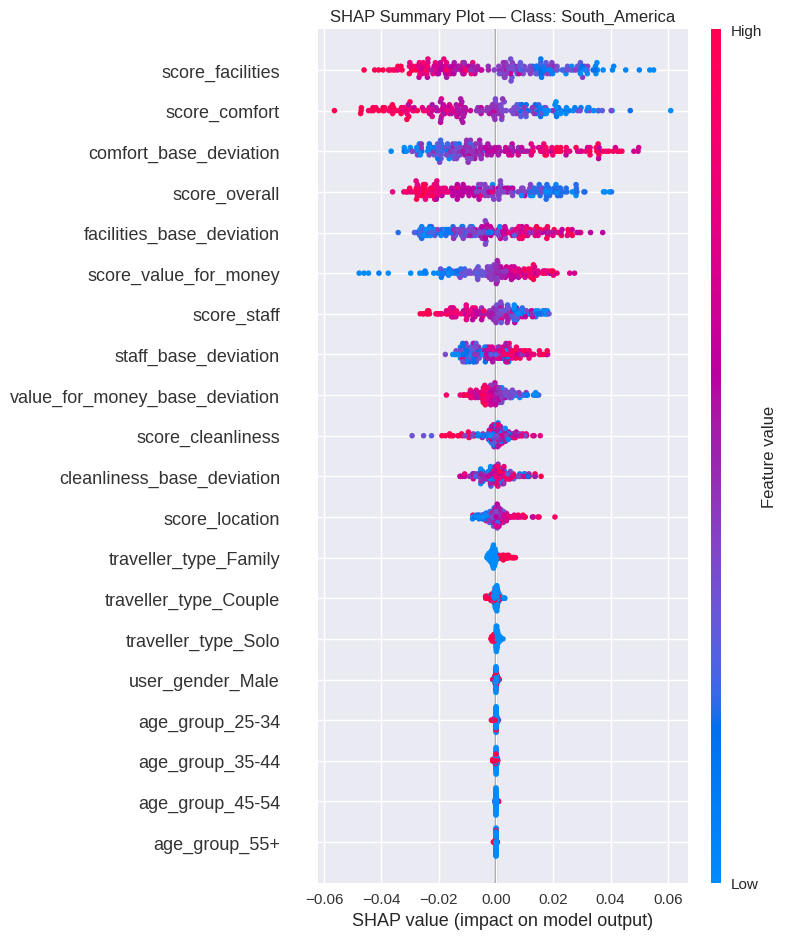


📊 Plotting SHAP summary for class: South_Asia


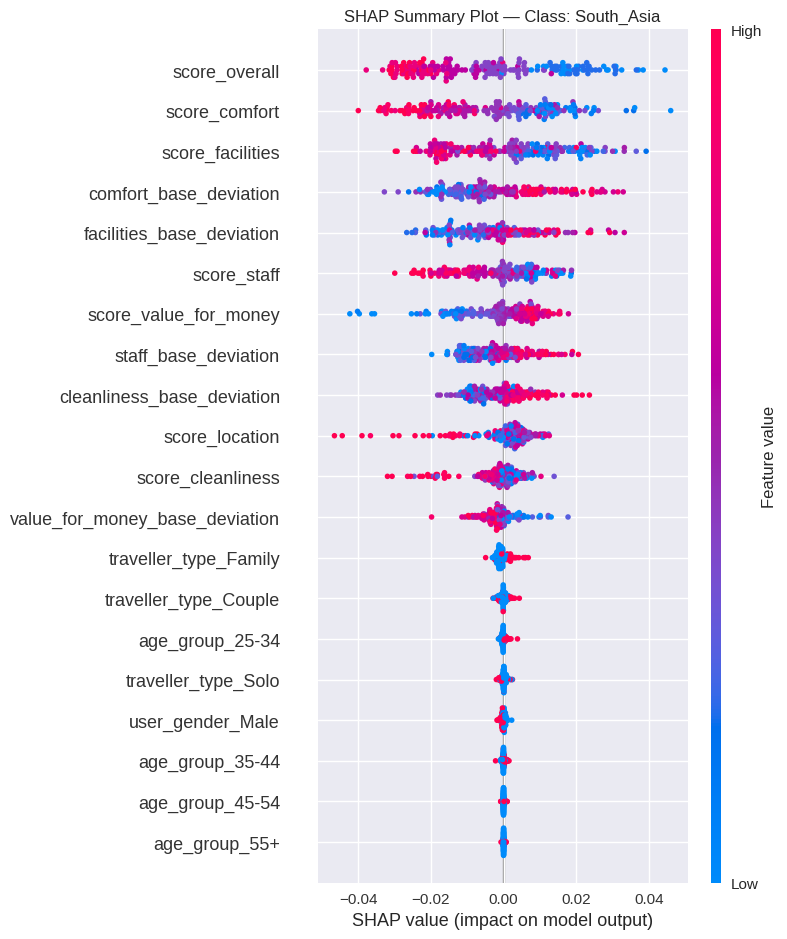


📊 Plotting SHAP summary for class: Southeast_Asia


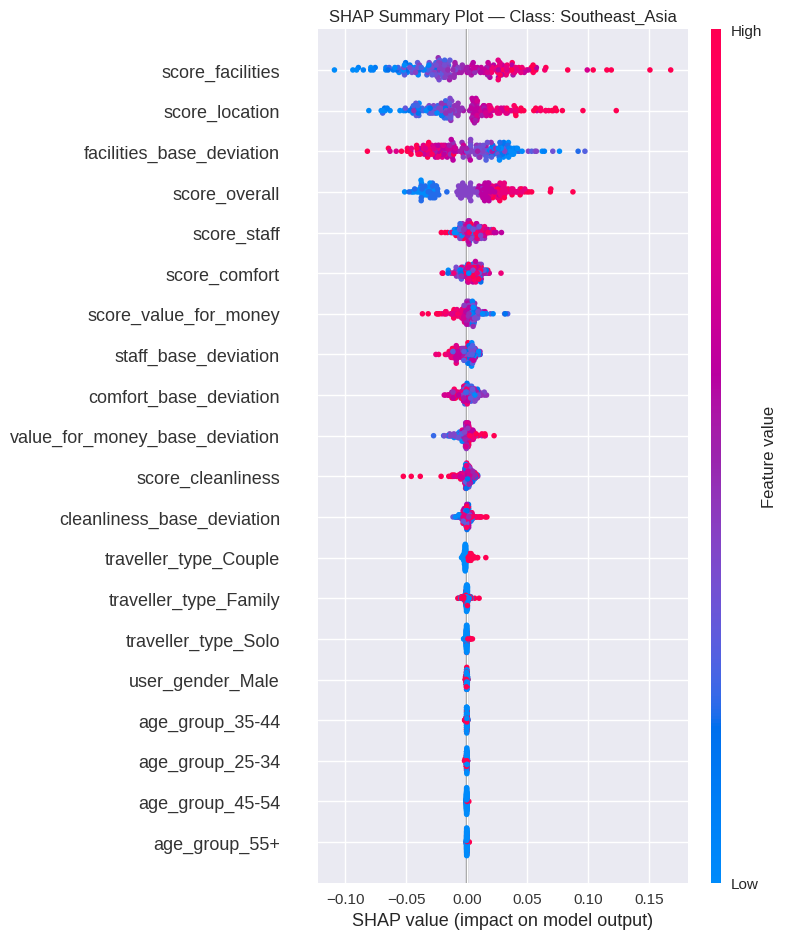


📊 Plotting SHAP summary for class: Western_Europe


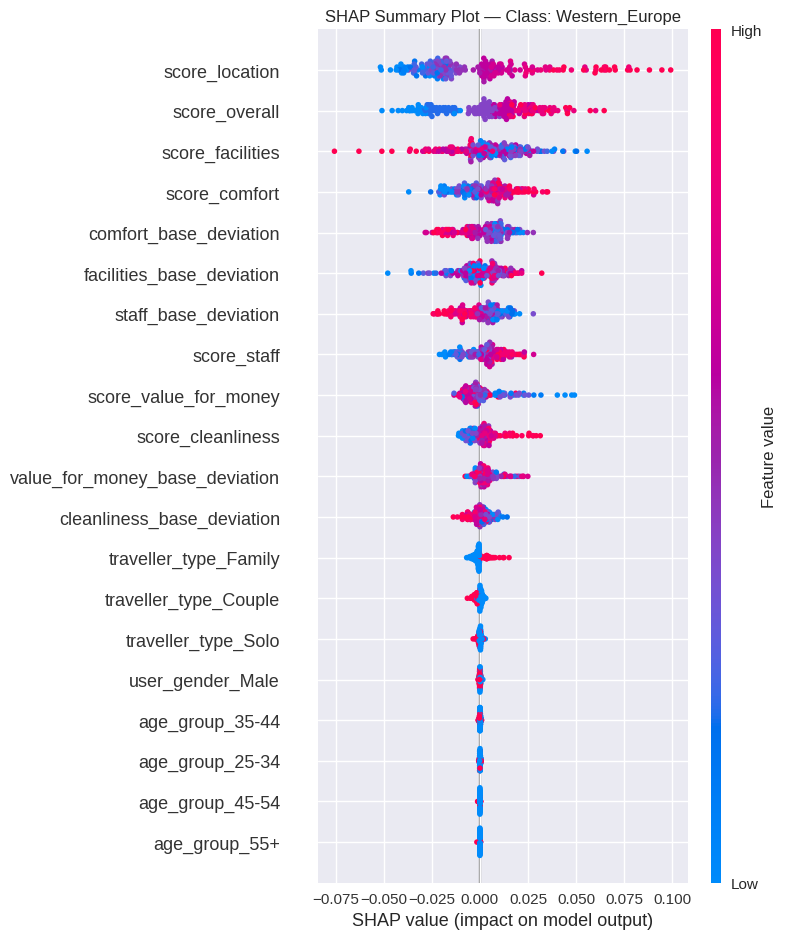

In [78]:
import shap
import matplotlib.pyplot as plt
import numpy as np

print("\n" + "="*60)
print("🔍 SHAP EXPLANATIONS (Multiclass Compatible)")
print("="*60)

# Convert scaled data back to DataFrames
X_train_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_df  = pd.DataFrame(X_test_scaled, columns=X_train.columns)

# Initialize SHAP TreeExplainer
explainer = shap.TreeExplainer(rf)

# ⚡ Sample for speed
X_sample = X_test_df.sample(200, random_state=42)

# Compute SHAP values (returns list for multiclass)
print("Computing SHAP values...")
shap_values = explainer.shap_values(X_sample)
print("✅ Done!")

# ===========================================
# 🌍 GLOBAL SHAP SUMMARY (per class)
# ===========================================
print("\n" + "="*60)
print("🌍 GLOBAL SHAP SUMMARY (Per Class)")
print("="*60)

# Plot for each class separately
for class_idx in range(len(shap_values)):
    class_name = le.inverse_transform([class_idx])[0]
    print(f"\n📊 Plotting SHAP summary for class: {class_name}")

    plt.title(f"SHAP Summary Plot — Class: {class_name}")
    shap.summary_plot(
        shap_values[class_idx],
        X_sample,
        plot_type="dot",   # red–blue grid
        show=True
    )


Explaining sample index 5 (true class: East_Asia)


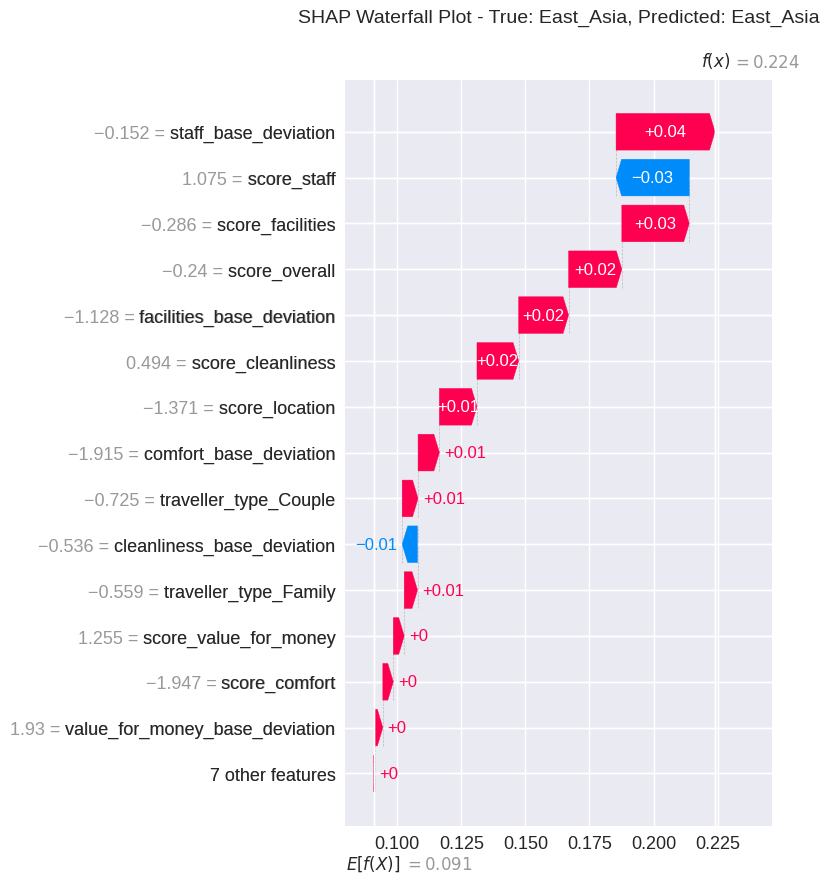


Explaining sample index 5 (true class: East_Asia)


<Figure size 3000x500 with 0 Axes>

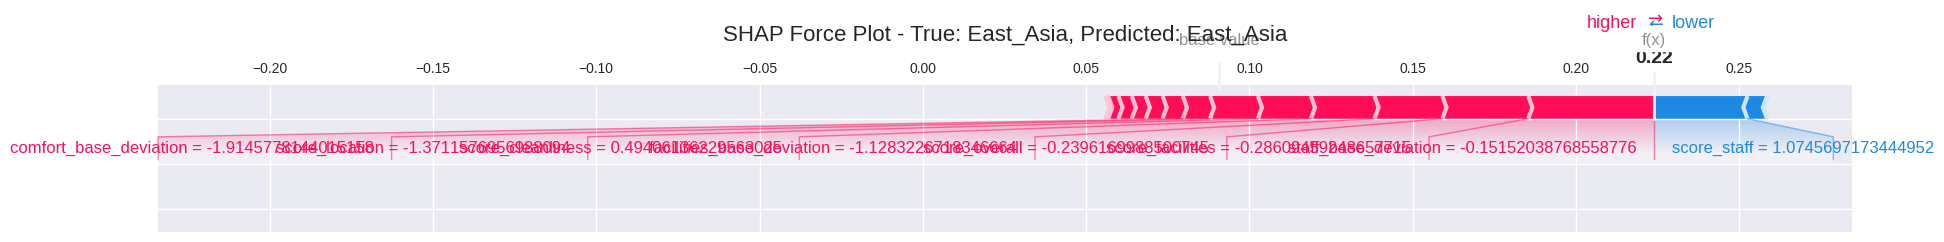

In [79]:
# WATERFALL PLOT - Better alternative for readability
i = 5
true_class = y_test[i] if not hasattr(y_test, "iloc") else y_test.iloc[i]
decoded_true_class = le.inverse_transform([true_class])[0]
print(f"\nExplaining sample index {i} (true class: {decoded_true_class})")

pred_class_idx = rf.predict(X_test_df.iloc[[i]])[0]

# Create SHAP explanation object
shap_explanation = shap.Explanation(
    values=shap_values[pred_class_idx][i, :],
    base_values=explainer.expected_value[pred_class_idx],
    data=X_test_df.iloc[i, :].values,
    feature_names=X_test_df.columns.tolist()
)

# Create LARGE waterfall plot
plt.figure(figsize=(12, 10))  # Tall and wide
plt.rcParams.update({'font.size': 12})
shap.plots.waterfall(shap_explanation, max_display=15, show=False)
plt.title(f"SHAP Waterfall Plot - True: {decoded_true_class}, Predicted: {le.classes_[pred_class_idx]}", 
          fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Fix for SHAP force plot - EXTRA LARGE VERSION
i = 5
true_class = y_test[i] if not hasattr(y_test, "iloc") else y_test.iloc[i]
decoded_true_class = le.inverse_transform([true_class])[0]
print(f"\nExplaining sample index {i} (true class: {decoded_true_class})")

pred_class_idx = rf.predict(X_test_df.iloc[[i]])[0]

# Create EXTRA LARGE figure
import matplotlib.pyplot as plt
plt.figure(figsize=(30, 5))  # MUCH WIDER AND TALLER!
plt.rcParams.update({'font.size': 14})  # Larger font

shap.initjs()
shap.force_plot(
    explainer.expected_value[pred_class_idx],
    shap_values[pred_class_idx][i, :],
    X_test_df.iloc[i, :],
    matplotlib=True,
    show=False
)
plt.title(f"SHAP Force Plot - True: {decoded_true_class}, Predicted: {le.classes_[pred_class_idx]}", 
          fontsize=16, pad=15)
plt.tight_layout()
plt.show()

In [80]:
# ===========================================
# LIME: Local Explanation
# ===========================================
print("\n" + "="*60)
print("💡 LIME EXPLANATION")
print("="*60)

lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train_df.values,
    feature_names=X_train_df.columns,
    class_names=le.classes_,
    mode='classification',
    discretize_continuous=True
)

# Explain the same sample
exp = lime_explainer.explain_instance(
    X_test_df.values[i],
    rf.predict_proba,
    num_features=10
)

# Show explanation inline
exp.show_in_notebook(show_table=True)


💡 LIME EXPLANATION


In [82]:
import numpy as np
import pandas as pd

def preprocess_input(raw_input):
    """
    Takes raw input dict and returns scaled input ready for model prediction.
    """
    model_features = X_train.columns.tolist()
    df = pd.DataFrame([raw_input])
    df_encoded = pd.get_dummies(df)
    df_encoded = df_encoded.reindex(columns=model_features, fill_value=0)
    scaled_input = scaler.transform(df_encoded)
    return scaled_input


def predict_country_group(raw_input):
    """
    Takes raw input dict, applies preprocessing, and returns a natural language prediction.
    """
    # Preprocess
    processed_input = preprocess_input(raw_input)

    # Predict probabilities
    probabilities = rf.predict_proba(processed_input)
    predicted_index = np.argmax(probabilities, axis=1)[0]
    predicted_label = le.inverse_transform([predicted_index])[0]
    confidence = probabilities[0][predicted_index]

    # Natural language explanation
    explanation = (
        f"Based on the provided hotel characteristics, "
        f"the model predicts that this review most likely belongs to the '{predicted_label}' country group "
        f"with a confidence of {confidence * 100:.2f}%."
    )

    return {
        "Predicted_Class": predicted_label,
        "Confidence": float(confidence),
        "Explanation": explanation
    }



# 🧾 Example raw input (dictionary)
sample_input = {
    "star_rating": "5",
    "comfort_base": "8.8",
    "facilities_base": "8.9"
}

# 🧩 Run inference
result = predict_country_group(sample_input)
print(result)


{'Predicted_Class': 'Africa', 'Confidence': 0.3903790553669775, 'Explanation': "Based on the provided hotel characteristics, the model predicts that this review most likely belongs to the 'Africa' country group with a confidence of 39.04%."}
